# GEEANNT version 1.4 Random Search

The direction $u_v = \cos(\theta _v)$ (as $s_v = atanh(u_v)$) is now modeled as a gaussian mixture:

$p(t_v|z) = \sum^K_{k=1}\, \pi_k\, \mathcal{N}(\mu _k;\sigma _k)$

where $\pi _k$ are the weights for the $K$ gaussians (suggested $K=[3;5]$)

To best fit the parameters we now use a Random Search algorithm sampling hypermaters in these ranges:

```
n_tv_mix        in {3, 5, 7}
w_sr            in [0.9, 1.2]
w_tv            in [0.8, 1.2]
w_phi_r         in [1.2, 1.8]
w_phi_v         in [0.9, 1.3]
w_xy            in [0.0, 0.03]
lambda_phi_r    in [1e-2, 4e-2]
lambda_phi      in [1e-2, 3e-2]
lambda_sigma    in [5e-4, 3e-3]
sigma_target    in [-2.8, -2.0]
lr              in [1e-4, 3e-4]

```

While mainting fixed

```
latent_dim = 12
hidden = (128,128,64,64,64)
beta = 0.1
min_log_sigma = -6.0
max_log_sigma = 1.5
```

The screening should be fast, therefore the epochs are 20, the early stopping has patience = 4.

The chosen library for this task in ```optuna```.

We need to define a *target metric*, for example:

```
score =
    a1 * KS_logE +
    a2 * KS_t_v +
    a3 * KS_u_v +
    a4 * KS_x +
    a5 * KS_y +
    a6 * KS_z +
    a7 * KS_vx +
    a8 * KS_vy +
    a9 * KS_vz +
    penalties_for_spikes
```

with an higher weight for $u_v$, $t_v$, $(x,y,z)$. An option could be:

```
score =
    1.5 * KS_u_v +
    1.2 * KS_t_v +
    1.0 * KS_x +
    1.0 * KS_y +
    1.0 * KS_z +
    0.8 * KS_logE +
    0.7 * KS_vx +
    0.7 * KS_vy +
    spike_penalty
```

In [2]:
# ==========================================================
# Imports
# ==========================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # reduce TensorFlow log verbosity

import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing

import scipy.stats as st
from scipy.stats import chi2, norm, ks_2samp, wasserstein_distance
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import c, m_e

from astropy.stats import poisson_conf_interval

from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from matplotlib import ticker
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D

# Hyperparameter optimization
import optuna

# ==========================================================
# TensorFlow / Keras
# Force CPU for this project, since it is faster than tf-metal
# for this specific custom CVAE on the M1 MacBook Air
# ==========================================================
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

from tensorflow import keras
from tensorflow.keras import layers
from keras import regularizers

# ==========================================================
# Reproducibility
# ==========================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ==========================================================
# Version / device checks
# ==========================================================
print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)

print("\nPhysical devices  :", tf.config.list_physical_devices())
print("Physical GPU(s)   :", tf.config.list_physical_devices("GPU"))

print("\nLogical devices   :", tf.config.list_logical_devices())
print("Logical GPU(s)    :", tf.config.list_logical_devices("GPU"))

TensorFlow version: 2.16.2
Keras version     : 3.12.1

Physical devices  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Physical GPU(s)   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Logical devices   : [LogicalDevice(name='/device:CPU:0', device_type='CPU')]
Logical GPU(s)    : []


## Dataset Import and Checks

In [3]:
col_list_Det = ["EventId", "ParticleName", "Energy", "X", "Y", "Z", "Vx", "Vy", "Vz"]
# force second column (index 1) to string, all others to float
dtype_map = {name: float for name in col_list_Det}
dtype_map[col_list_Det[1]] = str

#Data_K40 = pd.read_table('/Users/francesco/Desktop/Università/Magistrale/Tesi/Sim/S1GDMLSRON3Step/KDSourceTesting/alloutputDSCryoSphere.dat', names=col_list_Det, dtype=dtype_map)
Data_K40 = pd.read_table('/Users/francesco/Desktop/Università/Magistrale/Tesi/Sim/S1GDMLSRON3Step/GEEANNT/alloutputDSCryoSphereSmall.dat', names=col_list_Det, dtype=dtype_map)

# Remove the first column from Data_K40 (EventIds are not useful for ANN training)
Data_K40.drop(columns=["EventId"], inplace=True)

print("N righe:", len(Data_K40))
print(Data_K40.head())

# Controlli rapidi di NaN / inf
print("\nNaN per colonna:\n", Data_K40.isna().sum())
for c in ["Energy","X","Y","Z","Vx","Vy","Vz"]:
    bad = ~np.isfinite(Data_K40[c].to_numpy())
    if bad.any():
        print(f"Attenzione: {bad.sum()} valori non finiti in {c}")

N righe: 1873609
  ParticleName    Energy        X         Y        Z        Vx        Vy  \
0        gamma  0.150271  19.6164  90.88580 -473.600  0.096896 -0.990521   
1        gamma  0.091620 -31.8887 -82.91700 -463.909  0.913246  0.194270   
2        gamma  0.113628  94.9088   9.60548 -481.123 -0.169791  0.894456   
3        gamma  0.305449 -47.4416 -25.87610 -424.650  0.697276 -0.601885   
4        gamma  0.258675  21.8070  91.71120 -537.841 -0.668961 -0.634526   

         Vz  
0 -0.097358  
1 -0.358107  
2 -0.413667  
3 -0.389283  
4 -0.387128  

NaN per colonna:
 ParticleName    0
Energy          0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
dtype: int64


## Parameters Checks

Removed the clipping of $u_v$ which altered the distribution creating an artifact spike


--- Controllo sfera RAW (r = ||x-C||) ---
r: mean = 99.23411918434232  std = 0.40461867908293037  min = 98.93981564523723  max = 100.06006989051981
Deviazione media da R: 0.7682885734999307

--- Controllo norma direzione RAW (||v||) ---
||v||: mean = 0.9999999998903653  std = 2.88613664129066e-07  min = 0.9999991604741476  max = 1.0000008313726545
Deviazione media da 1: 2.402573376849245e-07

--- Controllo energia ---
E: min = 0.0011044  max = 1.46082  #E<=0 = 0

--- Controllo sfera PROIETTATA ---
r_proj: mean = 99.99999999999902  std = 2.2897201782837348e-14  min = 99.99999999999896  max = 99.99999999999903
Deviazione media da R: 1.0007113932897926e-12

--- Controllo direzione RINORMALIZZATA ---
||vhat||: mean = 0.9999999999990034  std = 3.408393483818028e-15  min = 0.9999999999989996  max = 0.9999999999990002
Deviazione media da 1: 1.0000542428995967e-12


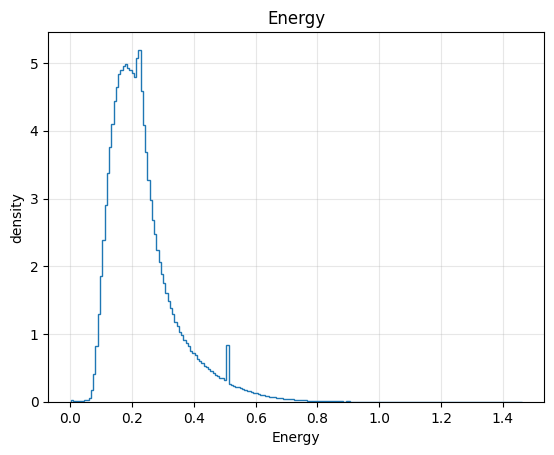

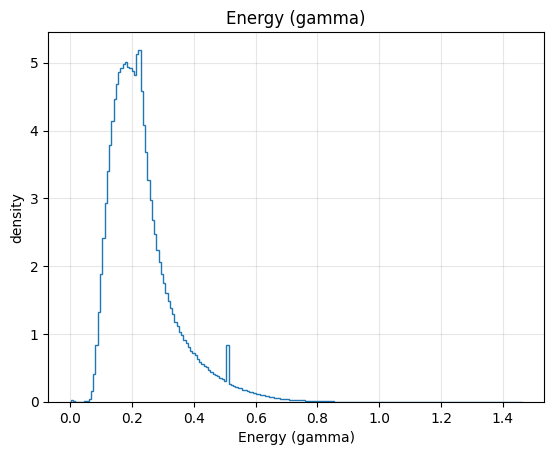

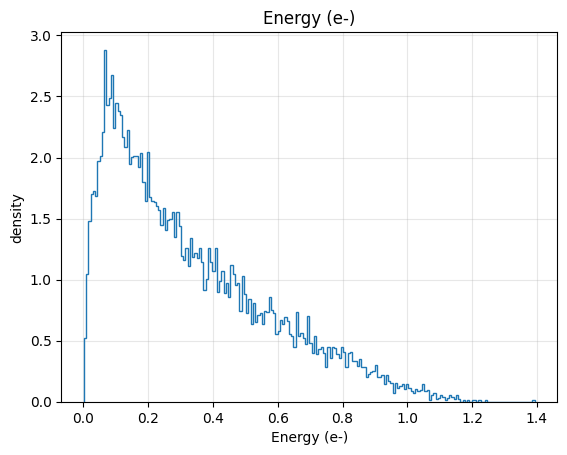

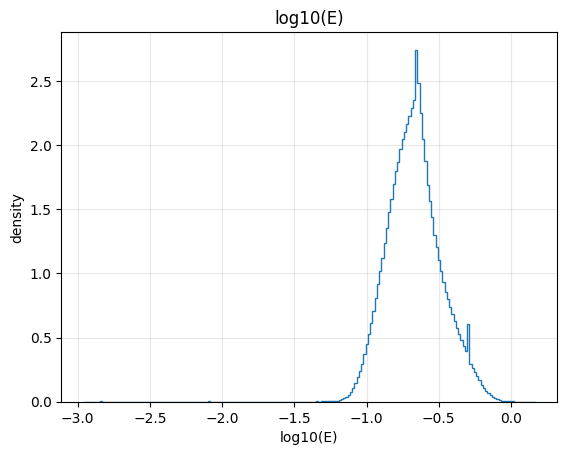

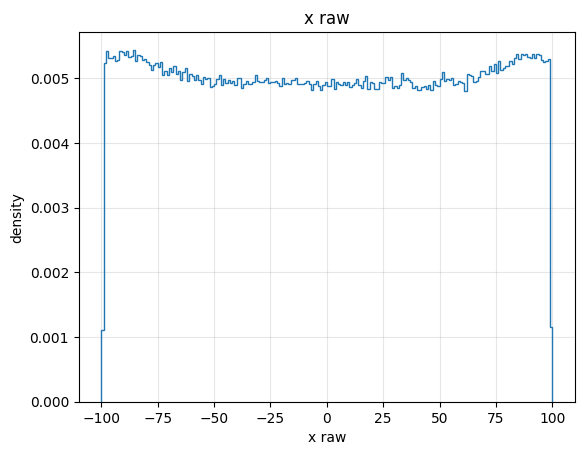

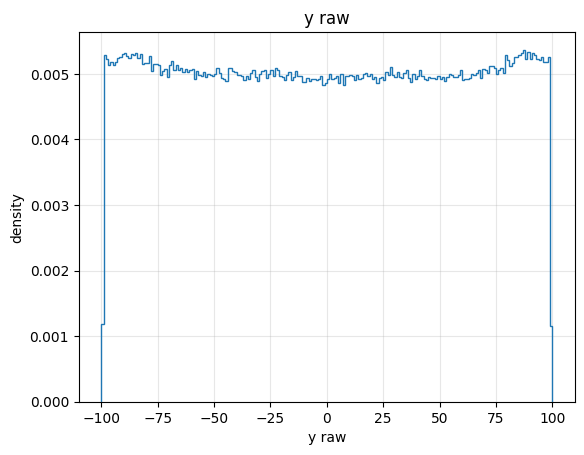

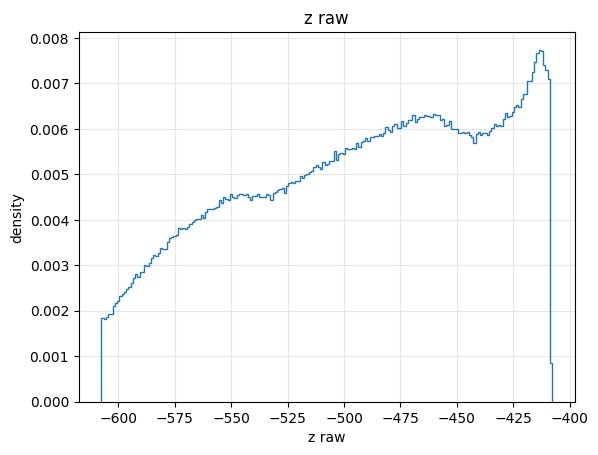

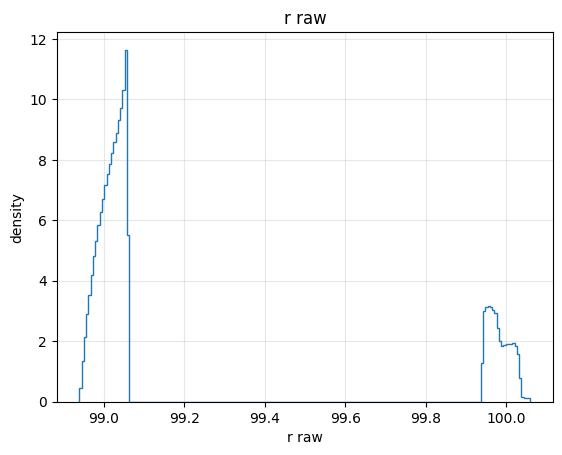

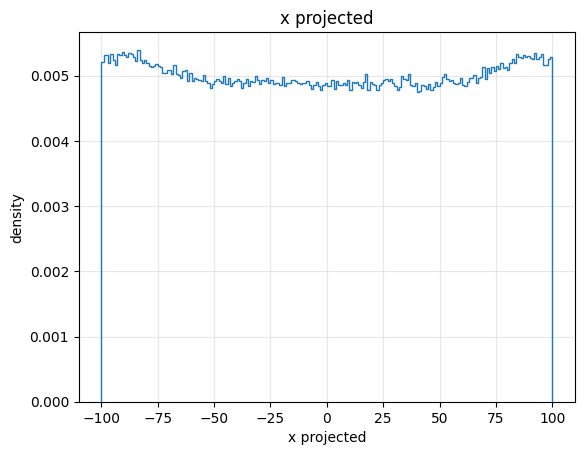

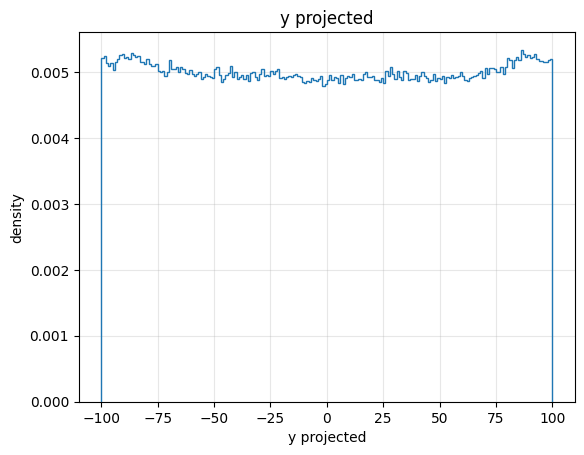

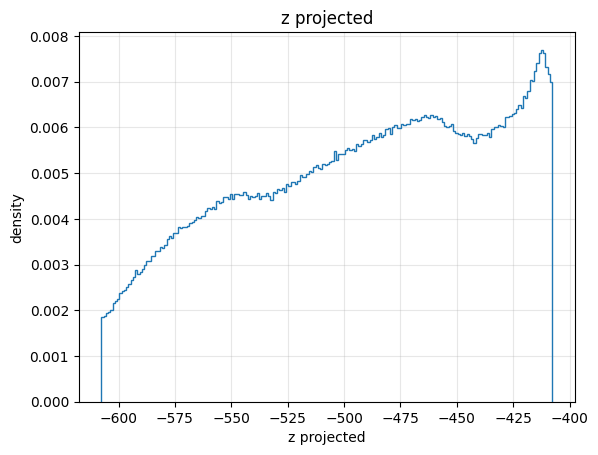

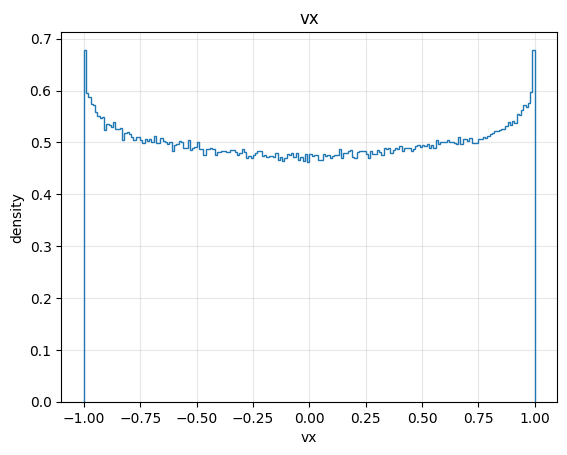

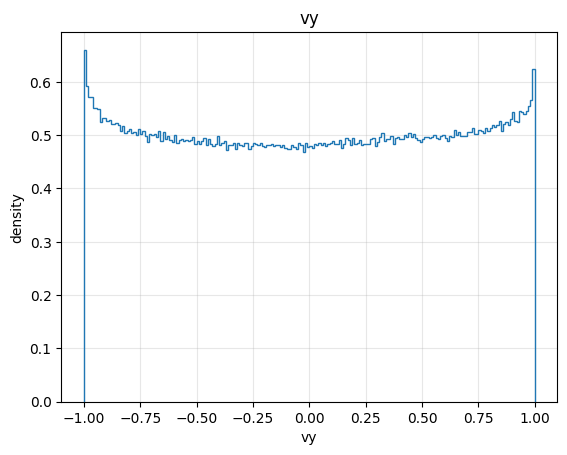

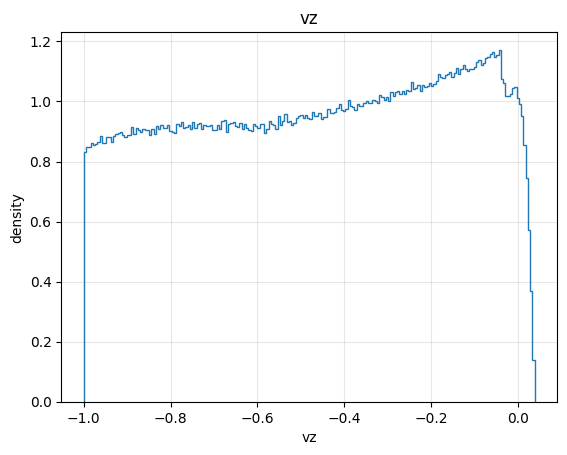

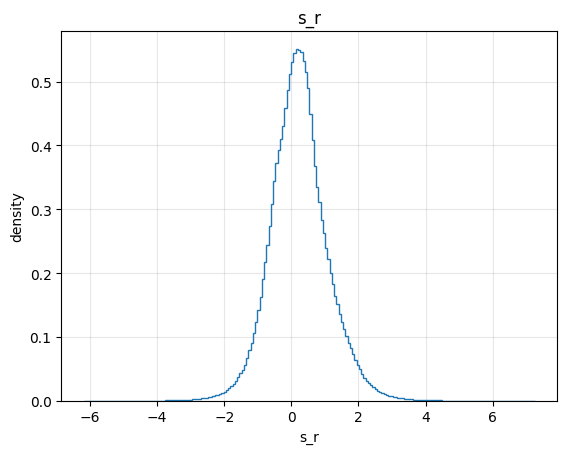

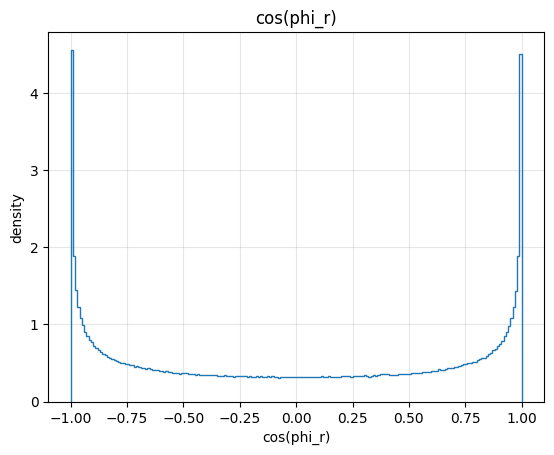

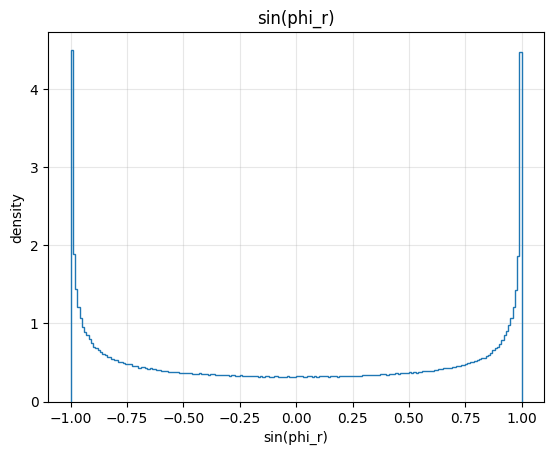

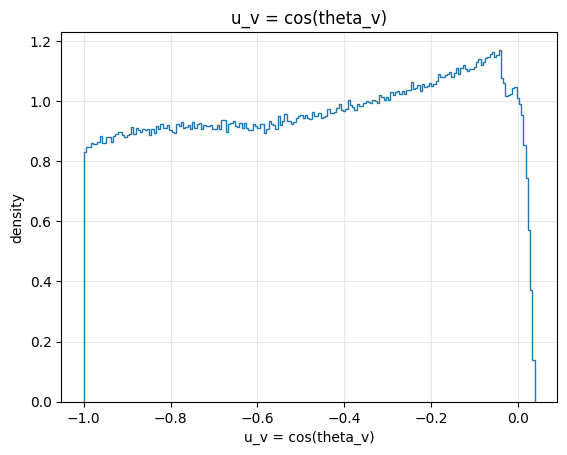

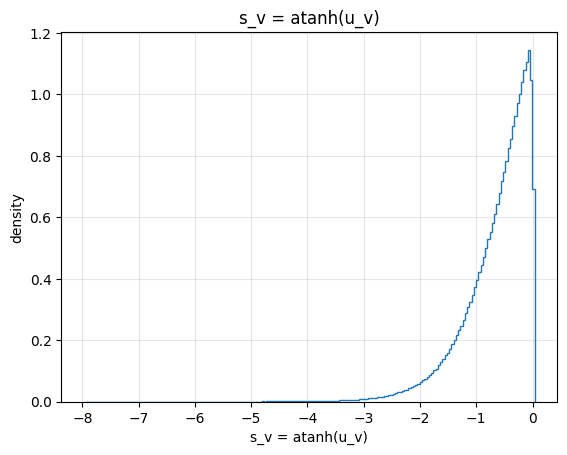

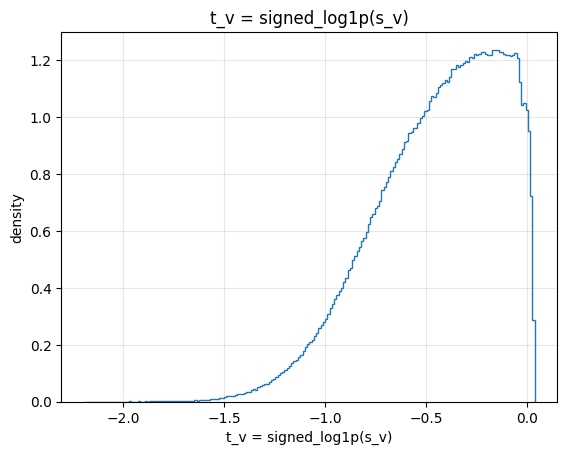

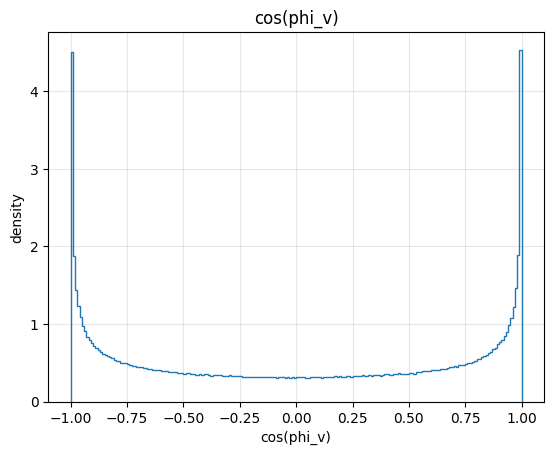

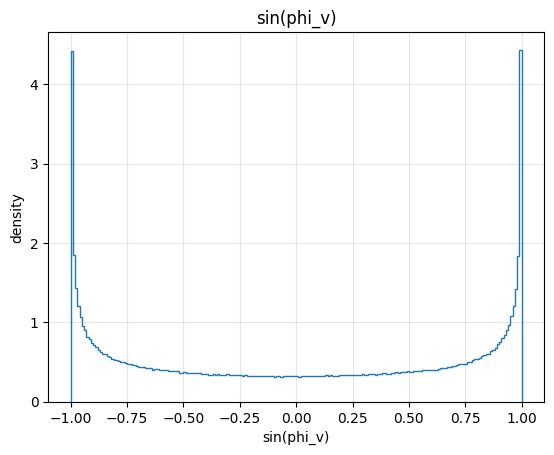


--- Check u_v / s_v / t_v ---
u_v: min = -0.9999997623463023 max = 0.039454388658001965 fraction u_v > 0 = 0.027152410134665236
s_v: min = -7.972799168107784 max = 0.03947488000882558 mean = -0.6359654243625891 std = 0.5727420147771567
t_v: min = -2.1941976862653534 max = 0.03871566256826599 mean = -0.44048208480719686 std = 0.3114601964350427

--- Check inversione signed-log ---
max |s_v_back - s_v| = 1.7763568394002505e-15
max |u_v_back - u_v| = 1.1102230246251565e-16


In [4]:
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

x = xyz[:, 0]
y = xyz[:, 1]
z = xyz[:, 2]

vx = v[:, 0]
vy = v[:, 1]
vz = v[:, 2]

# =========================
# Trasformazioni signed-log per s_v
# =========================

def signed_log1p(x):
    return np.sign(x) * np.log1p(np.abs(x))

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

# =========================
# Controlli fisici iniziali
# =========================

rvec = xyz - C[None, :]
r = np.linalg.norm(rvec, axis=1)
vnorm = np.linalg.norm(v, axis=1)

print("\n--- Controllo sfera RAW (r = ||x-C||) ---")
print("r: mean =", r.mean(), " std =", r.std(), " min =", r.min(), " max =", r.max())
print("Deviazione media da R:", np.mean(np.abs(r - R)))

print("\n--- Controllo norma direzione RAW (||v||) ---")
print("||v||: mean =", vnorm.mean(), " std =", vnorm.std(), " min =", vnorm.min(), " max =", vnorm.max())
print("Deviazione media da 1:", np.mean(np.abs(vnorm - 1.0)))

print("\n--- Controllo energia ---")
print("E: min =", E.min(), " max =", E.max(), " #E<=0 =", np.sum(E <= 0))

# =========================
# Filtro su energia valida
# =========================

mask_posE = (E > 0) & np.isfinite(E)
if not mask_posE.all():
    print(f"\nRimuovo {np.sum(~mask_posE)} righe con E<=0 o non finita.")
    Data_K40 = Data_K40.loc[mask_posE].reset_index(drop=True)

    xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
    v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
    E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    vx = v[:, 0]
    vy = v[:, 1]
    vz = v[:, 2]

    rvec = xyz - C[None, :]
    r = np.linalg.norm(rvec, axis=1)
    vnorm = np.linalg.norm(v, axis=1)

# =========================
# REGOLARIZZAZIONE POSIZIONE:
# proiezione di tutti i punti sulla sfera di raggio R
# =========================

rhat = rvec / (r[:, None] + 1e-12)
rvec_proj = R * rhat
xyz_proj = C[None, :] + rvec_proj

x_proj = xyz_proj[:, 0]
y_proj = xyz_proj[:, 1]
z_proj = xyz_proj[:, 2]

# check dopo proiezione
r_proj = np.linalg.norm(rvec_proj, axis=1)
print("\n--- Controllo sfera PROIETTATA ---")
print("r_proj: mean =", r_proj.mean(), " std =", r_proj.std(), " min =", r_proj.min(), " max =", r_proj.max())
print("Deviazione media da R:", np.mean(np.abs(r_proj - R)))

# =========================
# REGOLARIZZAZIONE DIREZIONE:
# rinormalizzo per sicurezza numerica
# =========================

vhat = v / (vnorm[:, None] + 1e-12)

vx_hat = vhat[:, 0]
vy_hat = vhat[:, 1]
vz_hat = vhat[:, 2]

vnorm_hat = np.linalg.norm(vhat, axis=1)
print("\n--- Controllo direzione RINORMALIZZATA ---")
print("||vhat||: mean =", vnorm_hat.mean(), " std =", vnorm_hat.std(), " min =", vnorm_hat.min(), " max =", vnorm_hat.max())
print("Deviazione media da 1:", np.mean(np.abs(vnorm_hat - 1.0)))

# =========================
# COSTRUZIONE FEATURE
# x = [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# dove:
#   u_v = cos(theta_v)
#   s_v = atanh(u_v)
#   t_v = sign(s_v) * log(1 + |s_v|)
# =========================

# -------------------------
# posizione dalla sfera proiettata
# -------------------------
u_r = np.clip(rhat[:, 2], -1.0 + eps, 1.0 - eps)
s_r = np.arctanh(u_r)

phi_r = np.arctan2(rhat[:, 1], rhat[:, 0])
cphi_r = np.cos(phi_r)
sphi_r = np.sin(phi_r)

# -------------------------
# direzione dal vettore rinormalizzato
# -------------------------
u_v = vz_hat #np.clip(vz_hat, -1.0 + eps, 1.0 - eps)
s_v = np.arctanh(u_v)

# nuova trasformazione smooth/compressa
t_v = signed_log1p(s_v)

phi_v = np.arctan2(vy_hat, vx_hat)
cphi_v = np.cos(phi_v)
sphi_v = np.sin(phi_v)

# energia
logE = np.log10(E)

# =========================
# Funzione per plot
# =========================

def plot_dist(data, name, bins=200):
    plt.figure()
    plt.hist(data, bins=bins, density=True, histtype="step")
    plt.xlabel(name)
    plt.ylabel("density")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================================
# Plot Energia
# ==========================================================
plot_dist(E, "Energy")
plot_dist(E[Data_K40["ParticleName"] == "gamma"], "Energy (gamma)")
plot_dist(E[Data_K40["ParticleName"] == "e-"], "Energy (e-)")
plot_dist(logE, "log10(E)")


# =========================
# Plot posizione RAW
# =========================

plot_dist(x, "x raw")
plot_dist(y, "y raw")
plot_dist(z, "z raw")
plot_dist(r, "r raw")

# =========================
# Plot posizione PROIETTATA
# =========================

plot_dist(x_proj, "x projected")
plot_dist(y_proj, "y projected")
plot_dist(z_proj, "z projected")
# plot_dist(r_proj, "r projected")

# =========================
# Plot direzioni
# =========================

plot_dist(vx_hat, "vx")
plot_dist(vy_hat, "vy")
plot_dist(vz_hat, "vz")

# =========================
# Plot feature posizione
# =========================

plot_dist(s_r, "s_r")
plot_dist(cphi_r, "cos(phi_r)")
plot_dist(sphi_r, "sin(phi_r)")

# =========================
# Plot feature direzione
# =========================

plot_dist(u_v, "u_v = cos(theta_v)")
plot_dist(s_v, "s_v = atanh(u_v)")
plot_dist(t_v, "t_v = signed_log1p(s_v)")
plot_dist(cphi_v, "cos(phi_v)")
plot_dist(sphi_v, "sin(phi_v)")

# =========================
# Check utili su u_v / s_v / t_v
# =========================

# inversione per controllo numerico
s_v_back = signed_expm1(t_v)
u_v_back = np.tanh(s_v_back)

print("\n--- Check u_v / s_v / t_v ---")
print("u_v: min =", u_v.min(), "max =", u_v.max(), "fraction u_v > 0 =", np.mean(u_v > 0))
print("s_v: min =", s_v.min(), "max =", s_v.max(), "mean =", s_v.mean(), "std =", s_v.std())
print("t_v: min =", t_v.min(), "max =", t_v.max(), "mean =", t_v.mean(), "std =", t_v.std())

print("\n--- Check inversione signed-log ---")
print("max |s_v_back - s_v| =", np.max(np.abs(s_v_back - s_v)))
print("max |u_v_back - u_v| =", np.max(np.abs(u_v_back - u_v)))

In [5]:
# ==========================================================
# Costruzione dataframe finale delle feature
# Ora usiamo:
#   u_v = cos(theta_v)
#   s_v = atanh(u_v)
#   t_v = sign(s_v) * log(1 + |s_v|)
#
# Feature finali:
# [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

# log energia
logE = np.log10(E)

# dataframe finale
feat = pd.DataFrame({
    "ParticleName": Data_K40["ParticleName"].astype(str).to_numpy(),
    "logE":   logE.astype(np.float32),
    "s_r":    s_r.astype(np.float32),
    "cphi_r": cphi_r.astype(np.float32),
    "sphi_r": sphi_r.astype(np.float32),
    "t_v":    t_v.astype(np.float32),
    "cphi_v": cphi_v.astype(np.float32),
    "sphi_v": sphi_v.astype(np.float32),
})

print("feat shape:", feat.shape)

print("\nPrime righe:")
display(feat.head())

# ==========================================================
# Check finitezza
# ==========================================================

print("\n--- Check finitezza ---")

arr = feat[["logE", "s_r", "cphi_r", "sphi_r", "t_v", "cphi_v", "sphi_v"]].to_numpy()
bad = ~np.isfinite(arr).all(axis=1)

print("Righe con NaN/Inf:", np.sum(bad))

# ==========================================================
# Range feature
# ==========================================================

print("\n--- Range feature ---")

for c in ["logE", "s_r", "cphi_r", "sphi_r", "t_v", "cphi_v", "sphi_v"]:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

# ==========================================================
# Check cerchi unitari
# ==========================================================

print("\n--- Check cerchi unitari ---")

cr = np.sqrt(feat["cphi_r"].to_numpy()**2 + feat["sphi_r"].to_numpy()**2)
cv = np.sqrt(feat["cphi_v"].to_numpy()**2 + feat["sphi_v"].to_numpy()**2)

print("pos: mean =", cr.mean(), "std =", cr.std(), "min =", cr.min(), "max =", cr.max())
print("dir: mean =", cv.mean(), "std =", cv.std(), "min =", cv.min(), "max =", cv.max())

# ==========================================================
# Check direzione fisica ricostruita
# t_v -> s_v -> u_v
# ==========================================================

print("\n--- Check u_v ricostruito ---")

s_v_check = signed_expm1(feat["t_v"].to_numpy())
u_v_check = np.tanh(s_v_check)

print("u_v: min =", u_v_check.min(), "max =", u_v_check.max())
print("fraction u_v > 0 =", np.mean(u_v_check > 0))

# ==========================================================
# Check distribuzione t_v
# ==========================================================

print("\n--- Check t_v ---")

print("t_v mean =", feat["t_v"].mean())
print("t_v std  =", feat["t_v"].std())
print("t_v min/max =", feat["t_v"].min(), feat["t_v"].max())

# ==========================================================
# Check distribuzione s_v ricostruita
# ==========================================================

print("\n--- Check s_v ricostruito da t_v ---")

print("s_v mean =", s_v_check.mean())
print("s_v std  =", s_v_check.std())
print("s_v min/max =", s_v_check.min(), s_v_check.max())

# ==========================================================
# Check inversione numerica
# ==========================================================

print("\n--- Check inversione t_v -> s_v -> u_v ---")
print("max |s_v_check - s_v| =", np.max(np.abs(s_v_check - s_v)))
print("max |u_v_check - u_v| =", np.max(np.abs(u_v_check - u_v)))

feat shape: (1873609, 8)

Prime righe:


,ParticleName,logE,s_r,cphi_r,sphi_r,t_v,cphi_v,sphi_v
0,gamma,-0.823125,0.358586,0.210977,0.977491,-0.093188,0.097358,-0.995249
1,gamma,-1.038010,0.474478,-0.358955,-0.933355,-0.318245,0.978114,0.208069
2,gamma,-0.944515,0.274716,0.994918,0.100693,-0.364662,-0.186496,0.982456
3,gamma,-0.515061,1.214620,-0.877904,-0.478836,-0.344266,0.756988,-0.653428
4,gamma,-0.587246,-0.314929,0.231329,0.972875,-0.342467,-0.725534,-0.688187



--- Check finitezza ---
Righe con NaN/Inf: 0

--- Range feature ---
    logE : -2.956873655319214  0.16459670662879944
     s_r : -6.184892177581787  7.254328727722168
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     t_v : -2.194197654724121  0.0387156642973423
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Check cerchi unitari ---
pos: mean = 1.0 std = 2.5750039e-08 min = 0.99999994 max = 1.0
dir: mean = 1.0 std = 2.5729706e-08 min = 0.99999994 max = 1.0

--- Check u_v ricostruito ---
u_v: min = -0.99999976 max = 0.03945439
fraction u_v > 0 = 0.027152410134665236

--- Check t_v ---
t_v mean = -0.44048217
t_v std  = 0.3114603
t_v min/max = -2.1941977 0.038715664

--- Check s_v ricostruito da t_v ---
s_v mean = -0.6359656
s_v std  = 0.57274204
s_v min/max = -7.972799 0.039474882

--- Check inversione t_v -> s_v -> u_v ---
max |s_v_check - s_v| = 8.760815175534731e-07
max |u_v_check - u_v| = 1.034359070617441e-07


## Standardization and Preprocessing

In [6]:
# ==========================================================
# Filter rare particle types + build RAW feature matrix
# Features:
# [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

prob_threshold = 1e-5

# ----------------------------------------------------------
# 1) Filter rare particle types
# ----------------------------------------------------------
type_counts_full = feat["ParticleName"].value_counts()
type_probs_full = type_counts_full / type_counts_full.sum()

valid_types = type_probs_full[type_probs_full >= prob_threshold].index

print("Original particle types:", len(type_counts_full))
print("Keeping particle types:", len(valid_types))
print("Dropping rare types:", len(type_counts_full) - len(valid_types))

feat = feat[feat["ParticleName"].isin(valid_types)].reset_index(drop=True)

# Recompute counts after filtering
type_counts = feat["ParticleName"].value_counts()
type_names = type_counts.index.to_list()
n_types = len(type_names)

type_to_idx = {t: i for i, t in enumerate(type_names)}
idx_to_type = {i: t for t, i in type_to_idx.items()}

type_probs = (type_counts / type_counts.sum()).to_numpy(dtype=np.float64)

print("\nNumero tipi:", n_types)
print("Tipi:", type_names)

print("\nProbabilità empiriche:")
for t, p in zip(type_names, type_probs):
    print(f"{t:>12s}  p={p:.6e}")

# ----------------------------------------------------------
# 2) Build RAW feature matrix
# ----------------------------------------------------------
cont_cols = ["logE", "s_r", "cphi_r", "sphi_r", "t_v", "cphi_v", "sphi_v"]

X_raw = feat[cont_cols].to_numpy(dtype=np.float32)

# Labels as integer indices
y_type = feat["ParticleName"].map(type_to_idx).to_numpy(dtype=np.int32)

print("\nX_raw shape:", X_raw.shape)
print("y_type shape:", y_type.shape)

# ----------------------------------------------------------
# 3) Sanity checks on RAW features
# ----------------------------------------------------------
print("\n--- Feature ranges (RAW) ---")
for c in cont_cols:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

print("\n--- Means/std (RAW) ---")
for j, c in enumerate(cont_cols):
    print(f"{c:>8s} : mean={X_raw[:, j].mean(): .6f}  std={X_raw[:, j].std(): .6f}")

# ----------------------------------------------------------
# 4) Check fisico aggiuntivo: u_v ricostruito da t_v
#    t_v -> s_v -> u_v
# ----------------------------------------------------------
t_v_raw = X_raw[:, 4]
s_v_from_tv = signed_expm1(t_v_raw)
u_v_from_tv = np.tanh(s_v_from_tv)

print("\n--- u_v reconstructed from t_v ---")
print("u_v: min =", u_v_from_tv.min(), "max =", u_v_from_tv.max())
print("fraction u_v > 0 =", np.mean(u_v_from_tv > 0))

Original particle types: 3
Keeping particle types: 2
Dropping rare types: 1

Numero tipi: 2
Tipi: ['gamma', 'e-']

Probabilità empiriche:
       gamma  p=9.926862e-01
          e-  p=7.313751e-03

X_raw shape: (1873594, 7)
y_type shape: (1873594,)

--- Feature ranges (RAW) ---
    logE : -2.956873655319214  0.16459670662879944
     s_r : -6.184892177581787  7.254328727722168
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     t_v : -2.194197654724121  0.0387156642973423
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Means/std (RAW) ---
    logE : mean=-0.670269  std= 0.186155
     s_r : mean= 0.225049  std= 0.849546
  cphi_r : mean=-0.002363  std= 0.708133
  sphi_r : mean=-0.001698  std= 0.706073
     t_v : mean=-0.440482  std= 0.311460
  cphi_v : mean= 0.001036  std= 0.709011
  sphi_v : mean= 0.002043  std= 0.705194

--- u_v reconstructed from t_v ---
u_v: min = -0.99999976 max = 0.03945439
fraction u_v > 0 = 0.027152627516954048


In [7]:
# ==========================================================
# Train / Validation / Test split
# 70% train, 15% val, 15% test
# SPLIT SU DATI RAW
#
# Feature layout:
# [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

test_size_total = 0.30
val_size_from_temp = 0.50   # metà del 30% -> 15% val, 15% test

idx_all = np.arange(len(X_raw))

idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all,
    y_type,
    test_size=test_size_total,
    random_state=42,
    stratify=y_type
)

idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp,
    y_temp,
    test_size=val_size_from_temp,
    random_state=42,
    stratify=y_temp
)

# ----------------------------------------------------------
# RAW splits
# ----------------------------------------------------------
X_train = X_raw[idx_train]
X_val   = X_raw[idx_val]
X_test  = X_raw[idx_test]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# ----------------------------------------------------------
# Utility: frazioni per tipo
# ----------------------------------------------------------
def frac_per_type(y_idx, n_types):
    c = np.bincount(y_idx, minlength=n_types).astype(np.float64)
    return c / c.sum()

print("\nCheck distribuzione tipi:")
print("All  :", frac_per_type(y_type,  n_types))
print("Train:", frac_per_type(y_train, n_types))
print("Val  :", frac_per_type(y_val,   n_types))
print("Test :", frac_per_type(y_test,  n_types))

# ----------------------------------------------------------
# Copie RAW esplicite per confronti fisici
# ----------------------------------------------------------
X_train_unscaled = X_train.copy()
X_val_unscaled   = X_val.copy()
X_test_unscaled  = X_test.copy()

print("\nRAW copies ready:")
print("X_train_unscaled:", X_train_unscaled.shape)
print("X_val_unscaled  :", X_val_unscaled.shape)
print("X_test_unscaled :", X_test_unscaled.shape)

# ----------------------------------------------------------
# Check fisico aggiuntivo: u_v ricostruito da t_v nei vari split
# t_v -> s_v -> u_v
# ----------------------------------------------------------
t_v_train = X_train[:, 4]
t_v_val   = X_val[:, 4]
t_v_test  = X_test[:, 4]

s_v_train = signed_expm1(t_v_train)
s_v_val   = signed_expm1(t_v_val)
s_v_test  = signed_expm1(t_v_test)

u_v_train = np.tanh(s_v_train)
u_v_val   = np.tanh(s_v_val)
u_v_test  = np.tanh(s_v_test)

print("\n--- Check u_v reconstructed from t_v ---")
print("Train u_v min/max:", u_v_train.min(), u_v_train.max(), " frac > 0 =", np.mean(u_v_train > 0))
print("Val   u_v min/max:", u_v_val.min(),   u_v_val.max(),   " frac > 0 =", np.mean(u_v_val > 0))
print("Test  u_v min/max:", u_v_test.min(),  u_v_test.max(),  " frac > 0 =", np.mean(u_v_test > 0))

Train: (1311515, 7) Val: (281039, 7) Test: (281040, 7)

Check distribuzione tipi:
All  : [0.99268625 0.00731375]
Train: [0.99268632 0.00731368]
Val  : [0.99268785 0.00731215]
Test : [0.99268432 0.00731568]

RAW copies ready:
X_train_unscaled: (1311515, 7)
X_val_unscaled  : (281039, 7)
X_test_unscaled : (281040, 7)

--- Check u_v reconstructed from t_v ---
Train u_v min/max: -0.99999976 0.03945439  frac > 0 = 0.02702523417574332
Val   u_v min/max: -0.9999909 0.038946796  frac > 0 = 0.027508637591223992
Test  u_v min/max: -0.99999905 0.039442282  frac > 0 = 0.02739111870196413


In [8]:
# ==========================================================
# Scaling SOLO su train
# Standardizziamo:
#   col 0 -> logE
#   col 1 -> s_r
#   col 4 -> t_v
# Lasciamo invariati:
#   cphi_r, sphi_r, cphi_v, sphi_v
#
# Feature layout:
# [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

from sklearn.preprocessing import StandardScaler
import numpy as np
import tensorflow as tf

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

scaler_cont = StandardScaler()

# fit solo su train RAW, sulle colonne continue non limitate
scale_cols = [0, 1, 4]   # logE, s_r, t_v
scaler_cont.fit(X_train[:, scale_cols])

def apply_selected_scaler(X_in, scaler, scale_cols):
    X_out = X_in.copy()
    X_out[:, scale_cols] = scaler.transform(X_in[:, scale_cols]).astype(np.float32)
    return X_out

X_train_s = apply_selected_scaler(X_train, scaler_cont, scale_cols)
X_val_s   = apply_selected_scaler(X_val,   scaler_cont, scale_cols)
X_test_s  = apply_selected_scaler(X_test,  scaler_cont, scale_cols)

print("Scaler means  :", scaler_cont.mean_)
print("Scaler std dev:", np.sqrt(scaler_cont.var_))

# ==========================================================
# Salvo per uso futuro
# ==========================================================

logE_mean = float(scaler_cont.mean_[0])
logE_std  = float(np.sqrt(scaler_cont.var_[0]))

s_r_mean  = float(scaler_cont.mean_[1])
s_r_std   = float(np.sqrt(scaler_cont.var_[1]))

t_v_mean  = float(scaler_cont.mean_[2])
t_v_std   = float(np.sqrt(scaler_cont.var_[2]))

print("\nSaved parameters:")
print("logE_mean =", logE_mean, " logE_std =", logE_std)
print("s_r_mean  =", s_r_mean,  " s_r_std  =", s_r_std)
print("t_v_mean  =", t_v_mean,  " t_v_std  =", t_v_std)

# ==========================================================
# Check rapidi
# ==========================================================

print("\n--- RAW ranges ---")
print("logE RAW train:", X_train[:, 0].min(), X_train[:, 0].max())
print("s_r  RAW train:", X_train[:, 1].min(), X_train[:, 1].max())
print("t_v  RAW train:", X_train[:, 4].min(), X_train[:, 4].max())

print("\n--- SCALED ranges ---")
print("logE scaled train:", X_train_s[:, 0].min(), X_train_s[:, 0].max())
print("s_r  scaled train:", X_train_s[:, 1].min(), X_train_s[:, 1].max())
print("t_v  scaled train:", X_train_s[:, 4].min(), X_train_s[:, 4].max())

print("\n--- Means/std AFTER scaling (train only) ---")
print("logE: mean =", X_train_s[:, 0].mean(), "std =", X_train_s[:, 0].std())
print("s_r : mean =", X_train_s[:, 1].mean(), "std =", X_train_s[:, 1].std())
print("t_v : mean =", X_train_s[:, 4].mean(), "std =", X_train_s[:, 4].std())

# check fisico utile: u_v ricostruito da t_v scalato -> unscaled -> s_v -> tanh
t_v_train_unscaled = X_train_s[:, 4] * t_v_std + t_v_mean
s_v_train_unscaled = signed_expm1(t_v_train_unscaled)
u_v_train_check = np.tanh(s_v_train_unscaled)

print("\n--- Check u_v reconstructed from scaled t_v ---")
print("u_v train min/max:", u_v_train_check.min(), u_v_train_check.max())
print("fraction u_v > 0 :", np.mean(u_v_train_check > 0))

# ==========================================================
# One-hot encoding dei tipi di particella
# ==========================================================

def to_one_hot(y_idx, n_types):
    y_idx = np.asarray(y_idx, dtype=np.int32)
    return tf.one_hot(y_idx, depth=n_types, dtype=tf.float32)

cond_train = to_one_hot(y_train, n_types)
cond_val   = to_one_hot(y_val,   n_types)
cond_test  = to_one_hot(y_test,  n_types)

print("\ncond_train shape:", cond_train.shape)
print("cond_val shape  :", cond_val.shape)
print("cond_test shape :", cond_test.shape)

print("\nExample one-hot rows:")
print(cond_train[:5])

if n_types >= 1:
    print("\nClass fractions in train:")
    for i in range(n_types):
        print(f"{idx_to_type[i]}:", cond_train[:, i].numpy().mean())

# ==========================================================
# Compute class weights from train set
# ==========================================================

counts_train = np.bincount(y_train, minlength=n_types).astype(np.float64)
freq_train = counts_train / counts_train.sum()

alpha = 0.5   # soft balancing

# inverse frequency weighting
w = (1.0 / np.maximum(freq_train, 1e-12)) ** alpha

# normalize so mean weight = 1
w = w / np.mean(w)

type_weights = tf.constant(w.astype(np.float32))

print("\nClass counts:", counts_train)
print("Class frequencies:", freq_train)
print("Class weights:", w)

# ==========================================================
# tf.data datasets
# ==========================================================

BATCH = 4096 
SHUFFLE_BUFFER = min(len(X_train_s), 200_000)

def make_dummy_targets(n):
    return tf.zeros((n, 1), dtype=tf.float32)

# ----------------------------------------------------------
# Train dataset
# ----------------------------------------------------------
train_ds = tf.data.Dataset.from_tensor_slices(
    ((X_train_s.astype(np.float32), cond_train),
     make_dummy_targets(len(X_train_s)))
)

train_ds = (
    train_ds
    .shuffle(SHUFFLE_BUFFER, reshuffle_each_iteration=True)
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ----------------------------------------------------------
# Validation dataset
# ----------------------------------------------------------
val_ds = tf.data.Dataset.from_tensor_slices(
    ((X_val_s.astype(np.float32), cond_val),
     make_dummy_targets(len(X_val_s)))
)

val_ds = (
    val_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ----------------------------------------------------------
# Test dataset
# ----------------------------------------------------------
test_ds = tf.data.Dataset.from_tensor_slices(
    ((X_test_s.astype(np.float32), cond_test),
     make_dummy_targets(len(X_test_s)))
)

test_ds = (
    test_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

print("\nDataset pronti.")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

# check rapido shapes
for (xb, cb), _ in train_ds.take(1):
    print("\nBatch check:")
    print("X batch shape   :", xb.shape)
    print("cond batch shape:", cb.shape)

Scaler means  : [-0.67034117  0.22511628 -0.4405434 ]
Scaler std dev: [0.18604365 0.85022931 0.31159359]

Saved parameters:
logE_mean = -0.670341170225532  logE_std = 0.18604364556068692
s_r_mean  = 0.2251162815842051  s_r_std  = 0.8502293079931205
t_v_mean  = -0.44054339865860437  t_v_std  = 0.31159359142634624

--- RAW ranges ---
logE RAW train: -2.9568737 0.08618893
s_r  RAW train: -6.184892 7.2543287
t_v  RAW train: -2.1941977 0.038715664

--- SCALED ranges ---
logE scaled train: -12.290301 4.066412
s_r  scaled train: -7.5391526 8.267431
t_v  scaled train: -5.628018 1.5380902

--- Means/std AFTER scaling (train only) ---
logE: mean = -1.3206584e-08 std = 1.0
s_r : mean = 1.396937e-08 std = 1.0
t_v : mean = 1.2376173e-08 std = 1.0

--- Check u_v reconstructed from scaled t_v ---
u_v train min/max: -0.99999976 0.039454386
fraction u_v > 0 : 0.02702523417574332

cond_train shape: (1311515, 2)
cond_val shape  : (281039, 2)
cond_test shape : (281040, 2)

Example one-hot rows:
tf.Tensor(

In [9]:
# ==========================================================
# Binning di logE (in spazio scalato)
# Serve per la categorical head dell'energia
# ==========================================================

n_logE_bins = 512   # prova 256 / 512 / 1024

logE_train_scaled = X_train_s[:, 0].astype(np.float32)

# ----------------------------------------------------------
# Costruzione edges dei bin
# ----------------------------------------------------------
logE_bin_edges = np.linspace(
    logE_train_scaled.min(),
    logE_train_scaled.max(),
    n_logE_bins + 1,
    dtype=np.float32
)

# centri dei bin (utili per diagnostica / generazione)
logE_bin_centers = 0.5 * (logE_bin_edges[:-1] + logE_bin_edges[1:])

# larghezza dei bin
logE_bin_width = logE_bin_edges[1] - logE_bin_edges[0]

print("n_logE_bins:", n_logE_bins)

print("\nlogE scaled min/max:")
print(logE_train_scaled.min(), logE_train_scaled.max())

print("\nbin width:", logE_bin_width)

print("\nFirst bin:", logE_bin_edges[0], logE_bin_edges[1])
print("Last bin :", logE_bin_edges[-2], logE_bin_edges[-1])

# ----------------------------------------------------------
# Check distribuzione occupazione bin
# ----------------------------------------------------------
logE_train_bins = np.digitize(logE_train_scaled, logE_bin_edges) - 1
logE_train_bins = np.clip(logE_train_bins, 0, n_logE_bins - 1)

counts = np.bincount(logE_train_bins, minlength=n_logE_bins)
empty_bins = np.sum(counts == 0)

print("\n--- Bin occupancy check ---")
print("min counts:", counts.min())
print("max counts:", counts.max())
print("empty bins:", empty_bins)
print("empty bin fraction:", empty_bins / n_logE_bins)

n_logE_bins: 512

logE scaled min/max:
-12.290301 4.066412

bin width: 0.031947136

First bin: -12.290301 -12.258354
Last bin : 4.0344653 4.066412

--- Bin occupancy check ---
min counts: 0
max counts: 21966
empty bins: 104
empty bin fraction: 0.203125


## Model and Training

In [10]:
# ==========================================================
# CVAE_CatLogE_MixGaussTV
# ==========================================================
#
# Conditional Variational Autoencoder with separate decoder heads for:
#   - logE with narrow spectral lines -> discretized categorical head
#   - s_r                             -> Gaussian head
#   - t_v = sign(s_v)*log(1+|s_v|), with s_v = atanh(u_v)
#                                       -> Mixture of Gaussians head
#   - (cphi_r, sphi_r)                -> 2D head with unit-circle regularization
#   - (cphi_v, sphi_v)                -> 2D head with unit-circle regularization
#
# INPUT / OUTPUT FEATURES
#   y = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
#
# where:
#   - logE_s, s_r_s, t_v_s are the scaled versions used during training
#   - cphi_*, sphi_* remain unscaled
#   - u_v = cos(theta_v) is not learned directly
#   - the following chain is used:
#
#         u_v -> s_v = atanh(u_v) -> t_v = sign(s_v) * log(1 + |s_v|)
#
# During generation:
#
#         t_v -> s_v = sign(t_v) * (exp(|t_v|)-1) -> u_v = tanh(s_v)
# ==========================================================


class CVAE_CatLogE_MixGaussTV(keras.Model):
    """
    Conditional VAE with separate heads.

    Input/output features:
      y = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
      cond = one-hot particle type

    Decoder heads:
      1) logE_s  -> categorical discretized head
      2) s_r_s   -> Gaussian head
      3) t_v_s   -> Mixture of Gaussians head
      4) phi_r   -> 2D head for (cphi_r, sphi_r)
      5) phi_v   -> 2D head for (cphi_v, sphi_v)
    """

    def __init__(
        self,
        n_types,
        logE_bin_edges,
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.1,
        type_weights=None,

        # Gaussian / mixture heads
        n_tv_mix=5,
        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        # regularization
        lambda_sigma=1e-3,
        sigma_target=-2.0,
        lambda_phi=1e-2,
        lambda_phi_r=1e-2,

        # reconstruction weights
        w_logE=1.0,
        w_sr=1.0,
        w_tv=1.0,
        w_phi_r=1.0,
        w_phi_v=1.0,

        # geometric xy-loss from position head
        w_xy=0.0,
        sphere_R=100.0,
    ):
        super().__init__()

        self.n_types = n_types
        self.latent_dim = latent_dim
        self.beta = beta
        self.type_weights = type_weights

        self.n_tv_mix = n_tv_mix
        self.min_log_sigma = min_log_sigma
        self.max_log_sigma = max_log_sigma

        self.lambda_sigma = lambda_sigma
        self.sigma_target = sigma_target
        self.lambda_phi = lambda_phi
        self.lambda_phi_r = lambda_phi_r

        self.w_logE = w_logE
        self.w_sr = w_sr
        self.w_tv = w_tv
        self.w_phi_r = w_phi_r
        self.w_phi_v = w_phi_v

        self.w_xy = w_xy
        self.sphere_R = sphere_R

        # ------------------------------------------------------
        # logE bins
        # ------------------------------------------------------
        logE_bin_edges = tf.convert_to_tensor(logE_bin_edges, dtype=tf.float32)
        self.logE_bin_edges = logE_bin_edges
        self.n_logE_bins = int(logE_bin_edges.shape[0] - 1)
        self.logE_bin_centers = 0.5 * (logE_bin_edges[:-1] + logE_bin_edges[1:])

        # ======================================================
        # Encoder
        # Input: y (7) + cond (n_types)
        # ======================================================
        enc_in = layers.Input(shape=(7 + n_types,))
        x = enc_in
        for h in hidden:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.05)(x)

        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)

        self.encoder = keras.Model(enc_in, [z_mean, z_logvar], name="encoder")

        # ======================================================
        # Decoder backbone
        # Input: z + cond
        # ======================================================
        dec_in = layers.Input(shape=(latent_dim + n_types,))
        x = dec_in
        for h in hidden[::-1]:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.01)(x)

        self.decoder_backbone = keras.Model(dec_in, x, name="decoder_backbone")

        # ======================================================
        # Decoder heads
        # ======================================================

        # 1) logE categorical head
        self.logE_logits_head = layers.Dense(self.n_logE_bins, name="logE_logits")

        # 2) s_r Gaussian head
        self.sr_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="sr_head")

        self.sr_mu_head = layers.Dense(1, name="sr_mu")
        self.sr_logsigma_head = layers.Dense(1, name="sr_logsigma")

        # 3) t_v mixture of Gaussians head
        self.tv_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="tv_head")

        self.tv_mix_logits_head = layers.Dense(self.n_tv_mix, name="tv_mix_logits")
        self.tv_mix_mu_head = layers.Dense(self.n_tv_mix, name="tv_mix_mu")
        self.tv_mix_logsigma_head = layers.Dense(self.n_tv_mix, name="tv_mix_logsigma")

        # 4) phi_r head
        self.phi_r_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.01),
            layers.Dense(2)
        ], name="phi_r_head")

        # 5) phi_v head
        self.phi_v_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.01),
            layers.Dense(2)
        ], name="phi_v_head")

        # ======================================================
        # Metrics
        # ======================================================
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec")
        self.kl_tracker = keras.metrics.Mean(name="kl")
        self.nll_tracker = keras.metrics.Mean(name="nll")

        self.sigma_reg_tracker = keras.metrics.Mean(name="sigma_reg")
        self.phi_reg_tracker = keras.metrics.Mean(name="phi_reg")
        self.phi_r_reg_tracker = keras.metrics.Mean(name="phi_r_reg")

        self.logE_ce_tracker = keras.metrics.Mean(name="logE_ce")
        self.sr_nll_tracker = keras.metrics.Mean(name="sr_nll")
        self.tv_nll_tracker = keras.metrics.Mean(name="tv_nll")
        self.phi_r_mse_tracker = keras.metrics.Mean(name="phi_r_mse")
        self.phi_v_mse_tracker = keras.metrics.Mean(name="phi_v_mse")
        self.xy_mse_tracker = keras.metrics.Mean(name="xy_mse")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.rec_tracker,
            self.kl_tracker,
            self.nll_tracker,
            self.sigma_reg_tracker,
            self.phi_reg_tracker,
            self.phi_r_reg_tracker,
            self.logE_ce_tracker,
            self.sr_nll_tracker,
            self.tv_nll_tracker,
            self.phi_r_mse_tracker,
            self.phi_v_mse_tracker,
            self.xy_mse_tracker,
        ]

    # ==========================================================
    # Utilities
    # ==========================================================
    def sample_z(self, z_mean, z_logvar):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps

    def _decode_params(self, z, cond, training=False):
        """
        Decode all head parameters from z and cond.
        """
        x = self.decoder_backbone(tf.concat([z, cond], axis=1), training=training)

        # 1) logE categorical head
        logE_logits = self.logE_logits_head(x)

        # 2) s_r Gaussian head
        sr_feat = self.sr_head(x)
        sr_mu = self.sr_mu_head(sr_feat)
        sr_logsigma = tf.clip_by_value(
            self.sr_logsigma_head(sr_feat),
            self.min_log_sigma,
            self.max_log_sigma
        )

        # 3) t_v Mixture of Gaussians head
        tv_feat = self.tv_head(x)
        tv_mix_logits = self.tv_mix_logits_head(tv_feat)
        tv_mix_mu = self.tv_mix_mu_head(tv_feat)
        tv_mix_logsigma = tf.clip_by_value(
            self.tv_mix_logsigma_head(tv_feat),
            self.min_log_sigma,
            self.max_log_sigma
        )

        # 4-5) angular heads
        phi_r = self.phi_r_head(x)
        phi_v = self.phi_v_head(x)

        return {
            "logE_logits": logE_logits,
            "sr_mu": sr_mu,
            "sr_logsigma": sr_logsigma,
            "tv_mix_logits": tv_mix_logits,
            "tv_mix_mu": tv_mix_mu,
            "tv_mix_logsigma": tv_mix_logsigma,
            "phi_r": phi_r,
            "phi_v": phi_v,
        }

    def _gaussian_nll(self, x, mu, log_sigma):
        """
        Gaussian negative log-likelihood up to an additive constant.
        """
        sigma2 = tf.exp(2.0 * log_sigma)
        return 0.5 * ((tf.square(x - mu) / sigma2) + 2.0 * log_sigma)

    def _mog_nll_1d(self, x, mix_logits, mix_mu, mix_logsigma):
        """
        Negative log-likelihood for a 1D Gaussian mixture.

        x:             (B, 1)
        mix_logits:    (B, K)
        mix_mu:        (B, K)
        mix_logsigma:  (B, K)
        returns:       (B,)
        """
        x = tf.squeeze(x, axis=1)
        x = tf.expand_dims(x, axis=1)

        log_pi = tf.nn.log_softmax(mix_logits, axis=1)
        sigma2 = tf.exp(2.0 * mix_logsigma)

        comp_log_prob = -0.5 * (
            tf.square(x - mix_mu) / sigma2 + 2.0 * mix_logsigma
        )

        log_prob = tf.reduce_logsumexp(log_pi + comp_log_prob, axis=1)
        return -log_prob

    def _logE_to_bin_index(self, logE_scaled):
        """
        logE_scaled: (B,1) or (B,)
        returns int indices in [0, n_bins-1]
        """
        x = tf.reshape(logE_scaled, [-1])
        boundaries = self.logE_bin_edges[1:-1]
        idx = tf.searchsorted(boundaries, x, side="right")
        idx = tf.cast(idx, tf.int32)
        return idx

    def _categorical_logE_nll(self, logE_scaled, logits):
        """
        Sparse cross-entropy on discretized logE.
        """
        idx = self._logE_to_bin_index(logE_scaled)
        ce = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=idx,
            logits=logits
        )
        return ce

    def _sigma_regularizer(self, params):
        """
        Penalize overly large sigmas.
        Acts on s_r sigma and all mixture sigmas of t_v.
        """
        if self.lambda_sigma <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        logsigmas = tf.concat([
            params["sr_logsigma"],
            params["tv_mix_logsigma"],
        ], axis=1)

        return self.lambda_sigma * tf.reduce_mean(
            tf.square(tf.nn.relu(logsigmas - self.sigma_target))
        )

    def _phi_regularizers(self, params):
        """
        Unit-circle regularization for angular heads:
        push c^2 + s^2 toward 1.
        """
        phi_r_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi_r > 0:
            c = params["phi_r"][:, 0]
            s = params["phi_r"][:, 1]
            r2 = c * c + s * s
            phi_r_reg = self.lambda_phi_r * tf.reduce_mean(tf.square(r2 - 1.0))

        phi_v_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi > 0:
            c = params["phi_v"][:, 0]
            s = params["phi_v"][:, 1]
            r2 = c * c + s * s
            phi_v_reg = self.lambda_phi * tf.reduce_mean(tf.square(r2 - 1.0))

        return phi_v_reg, phi_r_reg

    def _xy_from_sr_phi(self, s_r, phi_pair):
        """
        Reconstruct x and y from s_r and (cphi_r, sphi_r).
        """
        u_r = tf.tanh(tf.squeeze(s_r, axis=1))

        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        norm = tf.sqrt(c * c + s * s + 1e-12)
        c = c / norm
        s = s / norm

        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - u_r * u_r))

        x = self.sphere_R * sin_theta * c
        y = self.sphere_R * sin_theta * s
        return x, y

    def _reconstruction_terms(self, y_true, params):
        """
        y_true = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
        """
        logE_true = y_true[:, 0:1]
        sr_true = y_true[:, 1:2]
        phi_r_true = y_true[:, 2:4]
        tv_true = y_true[:, 4:5]
        phi_v_true = y_true[:, 5:7]

        # 1) logE categorical CE
        logE_ce = self._categorical_logE_nll(logE_true, params["logE_logits"])

        # 2) s_r Gaussian NLL
        sr_nll = tf.squeeze(
            self._gaussian_nll(sr_true, params["sr_mu"], params["sr_logsigma"]),
            axis=1
        )

        # 3) t_v Mixture-of-Gaussians NLL
        tv_nll = self._mog_nll_1d(
            tv_true,
            params["tv_mix_logits"],
            params["tv_mix_mu"],
            params["tv_mix_logsigma"]
        )

        # 4) angular heads
        phi_r_mse = tf.reduce_sum(tf.square(phi_r_true - params["phi_r"]), axis=1)
        phi_v_mse = tf.reduce_sum(tf.square(phi_v_true - params["phi_v"]), axis=1)

        # 5) geometric xy-loss derived from sr + phi_r
        x_true, y_true_xy = self._xy_from_sr_phi(sr_true, phi_r_true)
        x_pred, y_pred_xy = self._xy_from_sr_phi(params["sr_mu"], params["phi_r"])

        xy_mse = tf.square(x_true - x_pred) + tf.square(y_true_xy - y_pred_xy)

        rec_per = (
            self.w_logE  * logE_ce +
            self.w_sr    * sr_nll +
            self.w_tv    * tv_nll +
            self.w_phi_r * phi_r_mse +
            self.w_phi_v * phi_v_mse +
            self.w_xy    * xy_mse
        )

        pieces = {
            "logE_ce": logE_ce,
            "sr_nll": sr_nll,
            "tv_nll": tv_nll,
            "phi_r_mse": phi_r_mse,
            "phi_v_mse": phi_v_mse,
            "xy_mse": xy_mse,
        }
        return rec_per, pieces

    # ==========================================================
    # Keras train/test
    # ==========================================================
    def train_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x_in, training=True)
            z = self.sample_z(z_mean, z_logvar)

            params = self._decode_params(z, cond, training=True)
            rec_per, pieces = self._reconstruction_terms(y, params)

            if self.type_weights is not None:
                t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
                w = tf.gather(self.type_weights, t_idx)
                rec_per_weighted = rec_per * w
            else:
                rec_per_weighted = rec_per

            rec = tf.reduce_mean(rec_per_weighted)
            nll = tf.reduce_mean(rec_per)

            kl_per = -0.5 * tf.reduce_sum(
                1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
                axis=1
            )
            kl = tf.reduce_mean(kl_per)

            sigma_reg = self._sigma_regularizer(params)
            phi_reg, phi_r_reg = self._phi_regularizers(params)

            loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_ce_tracker.update_state(tf.reduce_mean(pieces["logE_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.tv_nll_tracker.update_state(tf.reduce_mean(pieces["tv_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (y, cond), _ = data
        x_in = tf.concat([y, cond], axis=1)

        z_mean, z_logvar = self.encoder(x_in, training=False)
        z = self.sample_z(z_mean, z_logvar)

        params = self._decode_params(z, cond, training=False)
        rec_per, pieces = self._reconstruction_terms(y, params)

        if self.type_weights is not None:
            t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
            w = tf.gather(self.type_weights, t_idx)
            rec_per_weighted = rec_per * w
        else:
            rec_per_weighted = rec_per

        rec = tf.reduce_mean(rec_per_weighted)
        nll = tf.reduce_mean(rec_per)

        kl_per = -0.5 * tf.reduce_sum(
            1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
            axis=1
        )
        kl = tf.reduce_mean(kl_per)

        sigma_reg = self._sigma_regularizer(params)
        phi_reg, phi_r_reg = self._phi_regularizers(params)

        loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.logE_ce_tracker.update_state(tf.reduce_mean(pieces["logE_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.tv_nll_tracker.update_state(tf.reduce_mean(pieces["tv_nll"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    # ==========================================================
    # Sampling / generation
    # ==========================================================
    @tf.function
    def decode(self, z, cond):
        return self._decode_params(z, cond, training=False)

    def _sample_logE_from_logits(self, logits):
        """
        Sample logE_s from categorical bins with uniform jitter inside the bin.
        logits: (B, n_bins)
        returns: (B,1)
        """
        bin_idx = tf.random.categorical(logits, num_samples=1)
        bin_idx = tf.squeeze(bin_idx, axis=1)

        edges_left = tf.gather(self.logE_bin_edges[:-1], bin_idx)
        edges_right = tf.gather(self.logE_bin_edges[1:], bin_idx)

        u = tf.random.uniform(tf.shape(edges_left), 0.0, 1.0)
        sample = edges_left + u * (edges_right - edges_left)

        return tf.expand_dims(sample, axis=1)

    def _sample_tv_from_mog(self, mix_logits, mix_mu, mix_logsigma, temperature=0.85):
        """
        Sample t_v from a 1D Gaussian mixture.

        mix_logits:    (B, K)
        mix_mu:        (B, K)
        mix_logsigma:  (B, K)
        returns:       (B,1)
        """
        comp_idx = tf.random.categorical(mix_logits, num_samples=1)
        comp_idx = tf.cast(tf.squeeze(comp_idx, axis=1), tf.int32)

        batch_idx = tf.range(tf.shape(mix_mu)[0], dtype=tf.int32)
        gather_idx = tf.stack([batch_idx, comp_idx], axis=1)

        mu = tf.gather_nd(mix_mu, gather_idx)
        logsigma = tf.gather_nd(mix_logsigma, gather_idx)

        eps = tf.random.normal(tf.shape(mu))
        sigma = tf.exp(logsigma) * temperature
        sample = mu + sigma * eps

        return tf.expand_dims(sample, axis=1)

    def generate_y(self, cond, n_samples):
        """
        Return y = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
        in the training feature space.
        """
        z = tf.random.normal((n_samples, self.latent_dim))
        params = self.decode(z, cond)

        # 1) logE categorical
        logE_s = self._sample_logE_from_logits(params["logE_logits"])

        # 2) s_r Gaussian
        sr_eps = tf.random.normal(tf.shape(params["sr_mu"]))
        s_r_s = params["sr_mu"] + tf.exp(params["sr_logsigma"]) * sr_eps

        # 3) t_v Mixture of Gaussians
        t_v_s = self._sample_tv_from_mog(
            params["tv_mix_logits"],
            params["tv_mix_mu"],
            params["tv_mix_logsigma"],
            temperature=0.90 # temperature increased for more variety in t_v
        )

        # 4) angular heads
        phi_r = params["phi_r"]
        phi_v = params["phi_v"]

        y = tf.concat([logE_s, s_r_s, phi_r, t_v_s, phi_v], axis=1)
        return y

#### Build Model Function for Optimization

We add here the model build function, such as we can then iteratively change the hyperparameter for each trial.

In [11]:
n_types = int(cond_train.shape[1])

# ==========================================================
# Hyperparameter tuning with Optuna
# ==========================================================

def build_model(trial):

    n_tv_mix = trial.suggest_categorical("n_tv_mix", [3,5,7])

    w_sr = trial.suggest_float("w_sr", 0.9, 1.2)
    w_tv = trial.suggest_float("w_tv", 0.8, 1.2)

    w_phi_r = trial.suggest_float("w_phi_r", 1.2, 1.8)
    w_phi_v = trial.suggest_float("w_phi_v", 0.9, 1.3)

    w_xy = trial.suggest_float("w_xy", 0.0, 0.03)

    lambda_phi = trial.suggest_float("lambda_phi", 1e-2, 3e-2)
    lambda_phi_r = trial.suggest_float("lambda_phi_r", 1e-2, 4e-2)

    lambda_sigma = trial.suggest_float("lambda_sigma", 5e-4, 3e-3)

    sigma_target = trial.suggest_float("sigma_target", -2.8, -2.0)

    lr = trial.suggest_float("lr", 1e-4, 3e-4, log=True)

    model = CVAE_CatLogE_MixGaussTV(
        n_types=n_types,
        logE_bin_edges=logE_bin_edges,

        latent_dim=12,
        hidden=(128,128,64,64,64),

        beta=0.1,
        type_weights=type_weights,

        n_tv_mix=n_tv_mix,

        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        lambda_sigma=lambda_sigma,
        sigma_target=sigma_target,
        lambda_phi=lambda_phi,
        lambda_phi_r=lambda_phi_r,

        w_logE=1.0,
        w_sr=w_sr,
        w_tv=w_tv,
        w_phi_r=w_phi_r,
        w_phi_v=w_phi_v,
        w_xy=w_xy,

        sphere_R=R,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(lr)
    )

    return model

We then build the objective function with the iteration of the model fit. At the beginning we can start by optimazing the validation loss, then, when we have found the 5-10 best set, we can perform a finer tuning with KS and Wasserstein metrics.

In [18]:
def objective(trial):

    model = build_model(trial)

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=15,  # fast tuning
        verbose=0
    )

    h = history.history

    # take best epoch values
    tv  = np.min(h["val_tv_nll"])
    sr  = np.min(h["val_sr_nll"])
    phr = np.min(h["val_phi_r_mse"])
    phv = np.min(h["val_phi_v_mse"])

    score = (
        tv +
        0.7 * sr +
        0.5 * phr +
        0.3 * phv
    )

    return score

In [19]:
# Run Optuna study

study = optuna.create_study(direction="minimize")

study.optimize(
    objective,
    n_trials=30
)

print(study.best_params) # best hyperparameters found by Optuna

[I 2026-03-14 16:35:52,572] A new study created in memory with name: no-name-0e644a98-831e-4eb1-bae8-1a2c13c2e2d8
[I 2026-03-14 16:39:11,692] Trial 0 finished with value: -0.2877194661647081 and parameters: {'n_tv_mix': 7, 'w_sr': 1.1360800060141352, 'w_tv': 0.8748914468149203, 'w_phi_r': 1.486357455695193, 'w_phi_v': 1.0321190870005288, 'w_xy': 0.0295838413050341, 'lambda_phi': 0.011987192983449815, 'lambda_phi_r': 0.01391040383175669, 'lambda_sigma': 0.002562754773302384, 'sigma_target': -2.0934520931103666, 'lr': 0.00011061285143950514}. Best is trial 0 with value: -0.2877194661647081.
[I 2026-03-14 16:42:54,973] Trial 1 finished with value: -2.7209277685731648 and parameters: {'n_tv_mix': 3, 'w_sr': 1.1632310732854423, 'w_tv': 0.8216783691728791, 'w_phi_r': 1.4653183062999409, 'w_phi_v': 1.006084033674038, 'w_xy': 0.0009536536052350863, 'lambda_phi': 0.012268968079572262, 'lambda_phi_r': 0.03619546011219357, 'lambda_sigma': 0.0019089451741260072, 'sigma_target': -2.620403155157189,

{'n_tv_mix': 3, 'w_sr': 0.9324769833021415, 'w_tv': 1.1868871327836161, 'w_phi_r': 1.237075766005713, 'w_phi_v': 1.1435453024275435, 'w_xy': 8.330341437215905e-05, 'lambda_phi': 0.011045106300912492, 'lambda_phi_r': 0.039656290187899436, 'lambda_sigma': 0.0008254970641212206, 'sigma_target': -2.5187493107399996, 'lr': 0.0001482878579477156}


Now we save the best N parameters (5-10) to reduce the intervals for the fine tuning.

The next cells will:

1. Save the N trials in a json file.

2. Extract the range for phase 2 tuning.

3. Define a new score function which takes into account generated values and physical resemblance of real distributions.

4. Initialize the model with the new ranges.

5. Define the new objective functions increasing the epochs of training.

6. Run Phase 2 with K trials (K=20).

7. Save the best 2-3 results.

8. Perform a full training.

In [20]:
# ==========================================================
# Save top-k Optuna trials from stage 1
# ==========================================================
import json

TOPK = 5
save_dir = "optuna_stage1_results"
os.makedirs(save_dir, exist_ok=True)

completed_trials = [
    t for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None
]

top_trials = sorted(completed_trials, key=lambda t: t.value)[:TOPK]

top_trials_summary = []
for rank, t in enumerate(top_trials, start=1):
    entry = {
        "rank": rank,
        "trial_number": t.number,
        "value": float(t.value),
        "params": t.params,
    }
    top_trials_summary.append(entry)

# Save JSON summary
json_path = os.path.join(save_dir, "top_trials_stage1.json")
with open(json_path, "w") as f:
    json.dump(top_trials_summary, f, indent=2)

print(f"Saved top {TOPK} trials to: {json_path}\n")

for entry in top_trials_summary:
    print(f"Rank {entry['rank']}: trial {entry['trial_number']}, score = {entry['value']:.6f}")
    print(entry["params"])
    print()

Saved top 5 trials to: optuna_stage1_results/top_trials_stage1.json

Rank 1: trial 10, score = -4.668438
{'n_tv_mix': 3, 'w_sr': 0.9324769833021415, 'w_tv': 1.1868871327836161, 'w_phi_r': 1.237075766005713, 'w_phi_v': 1.1435453024275435, 'w_xy': 8.330341437215905e-05, 'lambda_phi': 0.011045106300912492, 'lambda_phi_r': 0.039656290187899436, 'lambda_sigma': 0.0008254970641212206, 'sigma_target': -2.5187493107399996, 'lr': 0.0001482878579477156}

Rank 2: trial 11, score = -4.649126
{'n_tv_mix': 3, 'w_sr': 0.9227718432537907, 'w_tv': 1.1946267598482512, 'w_phi_r': 1.239694874506514, 'w_phi_v': 1.1602253291615703, 'w_xy': 0.0001166535458898197, 'lambda_phi': 0.010967436363075065, 'lambda_phi_r': 0.039487705358766244, 'lambda_sigma': 0.0007833032884978541, 'sigma_target': -2.5311708402655317, 'lr': 0.00015154743313685579}

Rank 3: trial 21, score = -3.620925
{'n_tv_mix': 3, 'w_sr': 1.015186357977231, 'w_tv': 1.168384313695097, 'w_phi_r': 1.5578351490560163, 'w_phi_v': 1.1532851334733185, 'w

In [23]:
# ==========================================================
# Build narrowed search ranges from top-k trials
# ==========================================================
def build_narrow_search_space(top_trials_summary):
    params_list = [entry["params"] for entry in top_trials_summary]

    def get_values(name):
        return [p[name] for p in params_list]

    narrow_space = {
        "n_tv_mix": sorted(list(set(get_values("n_tv_mix")))),

        "w_sr_min": max(0.85, min(get_values("w_sr")) - 0.01),
        "w_sr_max": min(1.25, max(get_values("w_sr")) + 0.01),

        "w_tv_min": max(0.75, min(get_values("w_tv")) - 0.01),
        "w_tv_max": min(1.25, max(get_values("w_tv")) + 0.01),

        "w_phi_r_min": max(1.1, min(get_values("w_phi_r")) - 0.02),
        "w_phi_r_max": min(1.8, max(get_values("w_phi_r")) + 0.02),

        "w_phi_v_min": max(0.85, min(get_values("w_phi_v")) - 0.02),
        "w_phi_v_max": min(1.35, max(get_values("w_phi_v")) + 0.02),

        "w_xy_min": max(0.0, min(get_values("w_xy")) - 0.003),
        "w_xy_max": min(0.03, max(get_values("w_xy")) + 0.003),

        "lambda_phi_min": max(1e-2, min(get_values("lambda_phi")) - 0.002),
        "lambda_phi_max": min(3e-2, max(get_values("lambda_phi")) + 0.002),

        "lambda_phi_r_min": max(1e-2, min(get_values("lambda_phi_r")) - 0.003),
        "lambda_phi_r_max": min(5e-2, max(get_values("lambda_phi_r")) + 0.003),

        "lambda_sigma_min": max(5e-4, min(get_values("lambda_sigma")) - 2e-4),
        "lambda_sigma_max": min(3e-3, max(get_values("lambda_sigma")) + 2e-4),

        "sigma_target_min": max(-2.9, min(get_values("sigma_target")) - 0.02),
        "sigma_target_max": min(-2.0, max(get_values("sigma_target")) + 0.02),

        "lr_min": max(8e-5, min(get_values("lr")) * 0.8),
        "lr_max": min(3e-4, max(get_values("lr")) * 1.2),
    }

    return narrow_space

narrow_space = build_narrow_search_space(top_trials_summary)

print("Narrow search space:")
for k, v in narrow_space.items():
    print(f"{k}: {v}")

Narrow search space:
n_tv_mix: [3]
w_sr_min: 0.9127718432537907
w_sr_max: 1.1732310732854423
w_tv_min: 0.811678369172879
w_tv_max: 1.2046267598482512
w_phi_r_min: 1.217075766005713
w_phi_r_max: 1.5778351490560163
w_phi_v_min: 0.986084033674038
w_phi_v_max: 1.2010485961910902
w_xy_min: 0.0
w_xy_max: 0.0039536536052350866
lambda_phi_min: 0.01
lambda_phi_max: 0.027185737049159782
lambda_phi_r_min: 0.032715418281450796
lambda_phi_r_max: 0.04265629018789944
lambda_sigma_min: 0.0005833032884978542
lambda_sigma_max: 0.0022566202134325533
sigma_target_min: -2.666317847467128
sigma_target_max: -2.4987493107399996
lr_min: 8.170450824391987e-05
lr_max: 0.0002664384351684863


In [24]:
# ==========================================================
# Utilities for stage-2 physical evaluation
# ==========================================================
def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c*c + s*s) + eps
    return c / r, s / r

def reconstruct_physical_from_features(X_in, C, R, eps=1e-6):
    """
    X_in layout:
    [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
    """
    X = np.asarray(X_in)

    logE = X[:, 0]

    # Position
    s_r = X[:, 1]
    u_r = np.tanh(s_r)

    cphi_r = X[:, 2].copy()
    sphi_r = X[:, 3].copy()
    cphi_r, sphi_r = renorm_cos_sin(cphi_r, sphi_r)

    sin_tr = np.sqrt(np.maximum(0.0, 1.0 - u_r**2))
    x = C[0] + R * sin_tr * cphi_r
    y = C[1] + R * sin_tr * sphi_r
    z = C[2] + R * u_r

    # Direction
    t_v = X[:, 4]
    s_v = signed_expm1(t_v)
    u_v = np.tanh(s_v)
    u_v = np.clip(u_v, -1.0 + eps, 1.0 - eps)

    cphi_v = X[:, 5].copy()
    sphi_v = X[:, 6].copy()
    cphi_v, sphi_v = renorm_cos_sin(cphi_v, sphi_v)

    sin_tv = np.sqrt(np.maximum(0.0, 1.0 - u_v**2))
    vx = sin_tv * cphi_v
    vy = sin_tv * sphi_v
    vz = u_v

    vnorm = np.sqrt(vx**2 + vy**2 + vz**2) + 1e-12
    vx /= vnorm
    vy /= vnorm
    vz /= vnorm

    return {
        "logE": logE,
        "t_v": t_v,
        "s_v": s_v,
        "u_v": u_v,
        "x": x,
        "y": y,
        "z": z,
        "vx": vx,
        "vy": vy,
        "vz": vz,
    }

def generate_unscaled_features(model, ngen, type_probs, n_types,
                               logE_mean, logE_std,
                               s_r_mean, s_r_std,
                               t_v_mean, t_v_std,
                               rng=None):
    gen_type_idx = sample_types(ngen, type_probs, rng=rng)
    gen_cond = one_hot_from_idx(gen_type_idx, n_types)

    y_gen_scaled = model.generate_y(gen_cond, ngen).numpy().astype(np.float32)
    y_gen = y_gen_scaled.copy()

    # unscale continuous columns
    y_gen[:, 0] = y_gen_scaled[:, 0] * logE_std + logE_mean
    y_gen[:, 1] = y_gen_scaled[:, 1] * s_r_std  + s_r_mean
    y_gen[:, 4] = y_gen_scaled[:, 4] * t_v_std  + t_v_mean

    return y_gen, gen_type_idx

In [25]:
# ==========================================================
# Prepare real validation reference for stage-2 scoring
# ==========================================================
C_eval = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R_eval = R

X_val_ref = X_val_unscaled.copy()
real_ref = reconstruct_physical_from_features(X_val_ref, C_eval, R_eval)

NGEN_STAGE2 = min(len(X_val_unscaled), 120_000)

print("Validation reference ready.")
for k in ["logE", "t_v", "u_v", "x", "y", "z", "vx", "vy", "vz"]:
    print(k, real_ref[k].shape)

Validation reference ready.
logE (281039,)
t_v (281039,)
u_v (281039,)
x (281039,)
y (281039,)
z (281039,)
vx (281039,)
vy (281039,)
vz (281039,)


In [26]:
# ==========================================================
# Stage-2 physical score
# ==========================================================
def histogram_spike_penalty(real, gen, bins=200, range_=None, spike_weight=1.0):
    real_hist, edges = np.histogram(real, bins=bins, range=range_, density=True)
    gen_hist, _ = np.histogram(gen, bins=edges, density=True)

    # Penalize bins where generated density strongly overshoots the real one
    excess = np.maximum(0.0, gen_hist - 1.25 * real_hist)
    return spike_weight * np.mean(excess)

def physical_score_from_generated(real_ref, gen_ref):
    # Wasserstein distances
    d_logE = wasserstein_distance(real_ref["logE"], gen_ref["logE"])
    d_t_v  = wasserstein_distance(real_ref["t_v"],  gen_ref["t_v"])
    d_u_v  = wasserstein_distance(real_ref["u_v"],  gen_ref["u_v"])
    d_x    = wasserstein_distance(real_ref["x"],    gen_ref["x"])
    d_y    = wasserstein_distance(real_ref["y"],    gen_ref["y"])
    d_z    = wasserstein_distance(real_ref["z"],    gen_ref["z"])
    d_vx   = wasserstein_distance(real_ref["vx"],   gen_ref["vx"])
    d_vy   = wasserstein_distance(real_ref["vy"],   gen_ref["vy"])
    d_vz   = wasserstein_distance(real_ref["vz"],   gen_ref["vz"])

    # Spike penalties
    p_uv = histogram_spike_penalty(real_ref["u_v"], gen_ref["u_v"], bins=200, range_=(-1, 1), spike_weight=3.0)
    p_x  = histogram_spike_penalty(real_ref["x"],   gen_ref["x"],   bins=200, spike_weight=1.5)
    p_y  = histogram_spike_penalty(real_ref["y"],   gen_ref["y"],   bins=200, spike_weight=1.5)
    p_z  = histogram_spike_penalty(real_ref["z"],   gen_ref["z"],   bins=200, spike_weight=1.5)

    score = (
        0.8 * d_logE +
        1.4 * d_t_v +
        1.8 * d_u_v +
        1.1 * d_x +
        1.1 * d_y +
        1.3 * d_z +
        0.6 * d_vx +
        0.6 * d_vy +
        0.5 * d_vz +
        p_uv + p_x + p_y + p_z
    )

    details = {
        "d_logE": d_logE,
        "d_t_v": d_t_v,
        "d_u_v": d_u_v,
        "d_x": d_x,
        "d_y": d_y,
        "d_z": d_z,
        "d_vx": d_vx,
        "d_vy": d_vy,
        "d_vz": d_vz,
        "p_uv": p_uv,
        "p_x": p_x,
        "p_y": p_y,
        "p_z": p_z,
        "score": score,
    }

    return score, details

In [27]:
# ==========================================================
# Build model for stage-2 narrowed search
# ==========================================================
def build_model_stage2(trial, narrow_space):

    n_tv_mix = trial.suggest_categorical("n_tv_mix", narrow_space["n_tv_mix"])

    w_sr = trial.suggest_float("w_sr", narrow_space["w_sr_min"], narrow_space["w_sr_max"])
    w_tv = trial.suggest_float("w_tv", narrow_space["w_tv_min"], narrow_space["w_tv_max"])

    w_phi_r = trial.suggest_float("w_phi_r", narrow_space["w_phi_r_min"], narrow_space["w_phi_r_max"])
    w_phi_v = trial.suggest_float("w_phi_v", narrow_space["w_phi_v_min"], narrow_space["w_phi_v_max"])

    w_xy = trial.suggest_float("w_xy", narrow_space["w_xy_min"], narrow_space["w_xy_max"])

    lambda_phi = trial.suggest_float("lambda_phi", narrow_space["lambda_phi_min"], narrow_space["lambda_phi_max"])
    lambda_phi_r = trial.suggest_float("lambda_phi_r", narrow_space["lambda_phi_r_min"], narrow_space["lambda_phi_r_max"])

    lambda_sigma = trial.suggest_float("lambda_sigma", narrow_space["lambda_sigma_min"], narrow_space["lambda_sigma_max"])

    sigma_target = trial.suggest_float("sigma_target", narrow_space["sigma_target_min"], narrow_space["sigma_target_max"])

    lr = trial.suggest_float("lr", narrow_space["lr_min"], narrow_space["lr_max"], log=True)

    model = CVAE_CatLogE_MixGaussTV(
        n_types=n_types,
        logE_bin_edges=logE_bin_edges,
        latent_dim=12,
        hidden=(128, 128, 64, 64, 64),
        beta=0.1,
        type_weights=type_weights,
        n_tv_mix=n_tv_mix,
        min_log_sigma=-6.0,
        max_log_sigma=1.5,
        lambda_sigma=lambda_sigma,
        sigma_target=sigma_target,
        lambda_phi=lambda_phi,
        lambda_phi_r=lambda_phi_r,
        w_logE=1.0,
        w_sr=w_sr,
        w_tv=w_tv,
        w_phi_r=w_phi_r,
        w_phi_v=w_phi_v,
        w_xy=w_xy,
        sphere_R=R,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(lr)
    )

    return model

In [28]:
# ==========================================================
# Stage-2 Optuna objective: 30 epochs + physical score
# ==========================================================
def objective_stage2(trial):

    model = build_model_stage2(trial, narrow_space)

    callbacks_stage2 = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=6,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=0
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks_stage2,
        verbose=0
    )

    # Generate validation-sized sample
    y_gen, gen_type_idx = generate_unscaled_features(
        model=model,
        ngen=NGEN_STAGE2,
        type_probs=type_probs,
        n_types=n_types,
        logE_mean=logE_mean,
        logE_std=logE_std,
        s_r_mean=s_r_mean,
        s_r_std=s_r_std,
        t_v_mean=t_v_mean,
        t_v_std=t_v_std,
        rng=np.random.default_rng(42),
    )

    gen_ref = reconstruct_physical_from_features(y_gen, C_eval, R_eval)

    phys_score, details = physical_score_from_generated(
        real_ref={k: v[:NGEN_STAGE2] for k, v in real_ref.items()},
        gen_ref=gen_ref
    )

    # Add a weak training-based term so wildly unstable models are penalized
    h = history.history
    aux_score = (
        0.15 * np.min(h["val_tv_nll"]) +
        0.08 * np.min(h["val_sr_nll"]) +
        0.05 * np.min(h["val_phi_r_mse"])
    )

    final_score = phys_score + aux_score

    # Save useful diagnostics in the trial
    for k, v in details.items():
        trial.set_user_attr(k, float(v))
    trial.set_user_attr("aux_score", float(aux_score))
    trial.set_user_attr("final_score", float(final_score))

    return final_score

In [29]:
# ==========================================================
# Run stage-2 Optuna study
# ==========================================================
study_stage2 = optuna.create_study(direction="minimize")

study_stage2.optimize(
    objective_stage2,
    n_trials=20  # you can start with 10-15, then extend
)

[I 2026-03-16 11:47:54,394] A new study created in memory with name: no-name-c41a3094-045d-41e7-84de-461c53c7b6ae
[I 2026-03-16 11:54:08,015] Trial 0 finished with value: 8.472910101174246 and parameters: {'n_tv_mix': 3, 'w_sr': 1.0044758649804542, 'w_tv': 1.1475404103452664, 'w_phi_r': 1.5432047642735922, 'w_phi_v': 1.0628327124558934, 'w_xy': 0.0022802344731843675, 'lambda_phi': 0.015199840550374011, 'lambda_phi_r': 0.040077426632468785, 'lambda_sigma': 0.0008899559818221653, 'sigma_target': -2.6231926708634825, 'lr': 0.00012875447787342927}. Best is trial 0 with value: 8.472910101174246.
[I 2026-03-16 12:01:22,090] Trial 1 finished with value: 6.829485964033229 and parameters: {'n_tv_mix': 3, 'w_sr': 1.1373009853668794, 'w_tv': 1.0271310975689414, 'w_phi_r': 1.3392426015388708, 'w_phi_v': 1.148095314425563, 'w_xy': 0.003938340809363024, 'lambda_phi': 0.02436628702596116, 'lambda_phi_r': 0.03354323595352452, 'lambda_sigma': 0.0008497062379540637, 'sigma_target': -2.5340289297926657, 

[I 2026-03-16 12:22:44,556] Trial 4 finished with value: 8.821883948549798 and parameters: {'n_tv_mix': 3, 'w_sr': 0.9402669052142337, 'w_tv': 1.0433435645088593, 'w_phi_r': 1.4204147427477707, 'w_phi_v': 1.0702447242188626, 'w_xy': 0.0013934324324738677, 'lambda_phi': 0.018594955006961546, 'lambda_phi_r': 0.0335589459554382, 'lambda_sigma': 0.0017973866268017624, 'sigma_target': -2.5856813126987346, 'lr': 9.048600342211353e-05}. Best is trial 3 with value: 6.3531095307650745.


[I 2026-03-16 12:30:56,319] Trial 5 finished with value: 7.3124376235421416 and parameters: {'n_tv_mix': 3, 'w_sr': 1.0783465764189566, 'w_tv': 0.8974336560139945, 'w_phi_r': 1.4631839328958078, 'w_phi_v': 1.1721986838755376, 'w_xy': 0.003802154643226618, 'lambda_phi': 0.024111692813839368, 'lambda_phi_r': 0.04195512058224091, 'lambda_sigma': 0.0017686634554139695, 'sigma_target': -2.6165729113801968, 'lr': 0.00022096238314825003}. Best is trial 3 with value: 6.3531095307650745.
[I 2026-03-16 12:38:45,264] Trial 6 finished with value: 8.028829318069793 and parameters: {'n_tv_mix': 3, 'w_sr': 1.0152741749026502, 'w_tv': 0.8261180398421046, 'w_phi_r': 1.5124237865028896, 'w_phi_v': 1.079411369248235, 'w_xy': 0.00364423824809573, 'lambda_phi': 0.020298056682368067, 'lambda_phi_r': 0.03580514086227113, 'lambda_sigma': 0.001292688995013976, 'sigma_target': -2.547525415870617, 'lr': 0.00022149181152125098}. Best is trial 3 with value: 6.3531095307650745.
[I 2026-03-16 12:46:56,584] Trial 7 f

In [30]:
# ==========================================================
# Save top-k trials from stage 2
# ==========================================================
TOPK2 = 3
save_dir_stage2 = "optuna_stage2_results"
os.makedirs(save_dir_stage2, exist_ok=True)

completed_trials_stage2 = [
    t for t in study_stage2.trials
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None
]

top_trials_stage2 = sorted(completed_trials_stage2, key=lambda t: t.value)[:TOPK2]

top_trials_stage2_summary = []
for rank, t in enumerate(top_trials_stage2, start=1):
    entry = {
        "rank": rank,
        "trial_number": t.number,
        "value": float(t.value),
        "params": t.params,
        "user_attrs": t.user_attrs,
    }
    top_trials_stage2_summary.append(entry)

json_path_stage2 = os.path.join(save_dir_stage2, "top_trials_stage2.json")
with open(json_path_stage2, "w") as f:
    json.dump(top_trials_stage2_summary, f, indent=2)

print(f"Saved top {TOPK2} stage-2 trials to: {json_path_stage2}\n")

for entry in top_trials_stage2_summary:
    print(f"Rank {entry['rank']}: trial {entry['trial_number']}, score = {entry['value']:.6f}")
    print(entry["params"])
    print("details:", entry["user_attrs"])
    print()

Saved top 3 stage-2 trials to: optuna_stage2_results/top_trials_stage2.json

Rank 1: trial 19, score = 5.055411
{'n_tv_mix': 3, 'w_sr': 0.9662561060596178, 'w_tv': 0.9088283910592649, 'w_phi_r': 1.2231404729128008, 'w_phi_v': 0.9896023067542146, 'w_xy': 0.002433896411025358, 'lambda_phi': 0.015267945817474638, 'lambda_phi_r': 0.03893991750503517, 'lambda_sigma': 0.0019623680898822465, 'sigma_target': -2.6431677803251072, 'lr': 0.00018353928530367}
details: {'d_logE': 0.004481701032669905, 'd_t_v': 0.026803479790131493, 'd_u_v': 0.026774851220078996, 'd_x': 1.0225392207489687, 'd_y': 1.5738216929575684, 'd_z': 1.96154720433553, 'd_vx': 0.025871711672112427, 'd_vy': 0.006813098226540769, 'd_vz': 0.026774851220078996, 'p_uv': 0.005012499416464631, 'p_x': 9.535197780077765e-07, 'p_y': 4.718832375113411e-06, 'p_z': 7.25407359559926e-07, 'score': 5.533330544167051, 'aux_score': -0.47792000949382785, 'final_score': 5.055410534673223}

Rank 2: trial 18, score = 6.005085
{'n_tv_mix': 3, 'w_sr':

Here below are the cells used in single training which can be later used for fine tuning.

In [ ]:
'''
# Instanzia il nuovo modello e fai il fit
n_types = int(cond_train.shape[1])

model = CVAE_CatLogE_MixGaussTV(
    n_types=n_types,
    logE_bin_edges=logE_bin_edges,   # logE bins in scaled space
    latent_dim=12,
    hidden=(128, 128, 64, 64, 64),
    beta=0.1,
    type_weights=type_weights,

    # Mixture-of-Gaussians head for t_v
    n_tv_mix=5, # try 3 / 5 / 7, increased from 3 to 5 to 7 for better modeling of t_v distribution

    # Gaussian / mixture sigma control
    min_log_sigma=-6.0,
    max_log_sigma=1.5,

    # Regularization
    lambda_sigma=2e-3, # increased from 1e-3 to 2e-3 for stronger penalty on large sigmas for t_v distribution
    sigma_target=-2.5, # decreased from -2.0 to -2.5 to encourage tighter distributions, especially for t_v
    lambda_phi=2e-2,
    lambda_phi_r=2e-2,

    # Reconstruction weights
    w_logE=1.0,
    w_sr=1.1,      # weight on s_r NLL, increased from 1.0 to 1.1 to balance with other terms
    w_tv=1.0,      # weight on transformed directional variable t_v, decreased from 1.1 to 1.0 to balance with other terms
    w_phi_r=1.4,   # weight on phi_r MSE, increased from 1.0 to 1.5 for stronger geometric regularization on position head
    w_phi_v=1.1,

    # Geometric xy-loss
    w_xy=0.02, # weight on xy-loss derived from s_r and phi_r, increased from 0.01 to 0.02 for stronger geometric regularization


    # Sphere geometry used in xy-loss
    sphere_R=R,
)

model.compile(
    optimizer=keras.optimizers.Adam(2e-4)
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8, #reduced from 10 to 8 for earlier stopping given improved training stability
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=4, # reduced from 5 to 4 for more responsive learning rate reduction
        min_lr=1e-5,
        verbose=1
    ),
]
'''

In [ ]:
'''
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)
'''

Epoch 1/60
321/321 ━━━━━━━━━━━━━━━━━━━━ 17s 41ms/step - kl: 6.3237 - logE_ce: 5.6103 - loss: 14.6363 - nll: 81.6472 - phi_r_mse: 0.4976 - phi_r_reg: 0.0117 - phi_reg: 0.0172 - phi_v_mse: 0.9521 - rec: 13.9656 - sigma_reg: 0.0093 - sr_nll: 1.1220 - tv_nll: 0.4184 - xy_mse: 3632.0132 - val_kl: 10.5713 - val_logE_ce: 5.1994 - val_loss: 3.9507 - val_nll: 16.5681 - val_phi_r_mse: 0.1195 - val_phi_r_reg: 0.0055 - val_phi_reg: 0.0156 - val_phi_v_mse: 0.9088 - val_rec: 2.8653 - val_sigma_reg: 0.0070 - val_sr_nll: 0.7367 - val_tv_nll: 0.3401 - val_xy_mse: 452.5662 - learning_rate: 2.0000e-04
Epoch 2/60
321/321 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - kl: 10.3515 - logE_ce: 5.0141 - loss: 2.8850 - nll: 10.5252 - phi_r_mse: 0.0596 - phi_r_reg: 0.0028 - phi_reg: 0.0149 - phi_v_mse: 0.8907 - rec: 1.8260 - sigma_reg: 0.0061 - sr_nll: 0.5192 - tv_nll: 0.3602 - xy_mse: 175.8318 - val_kl: 9.4742 - val_logE_ce: 4.9246 - val_loss: 2.5466 - val_nll: 9.1163 - val_phi_r_mse: 0.0357 - val_phi_r_reg: 0.0016 - val


Available history keys:
['kl', 'logE_ce', 'loss', 'nll', 'phi_r_mse', 'phi_r_reg', 'phi_reg', 'phi_v_mse', 'rec', 'sigma_reg', 'sr_nll', 'tv_nll', 'val_kl', 'val_logE_ce', 'val_loss', 'val_nll', 'val_phi_r_mse', 'val_phi_r_reg', 'val_phi_reg', 'val_phi_v_mse', 'val_rec', 'val_sigma_reg', 'val_sr_nll', 'val_tv_nll', 'val_xy_mse', 'xy_mse', 'learning_rate']


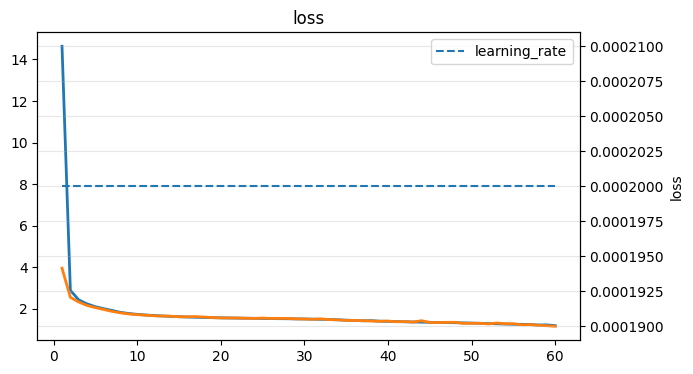

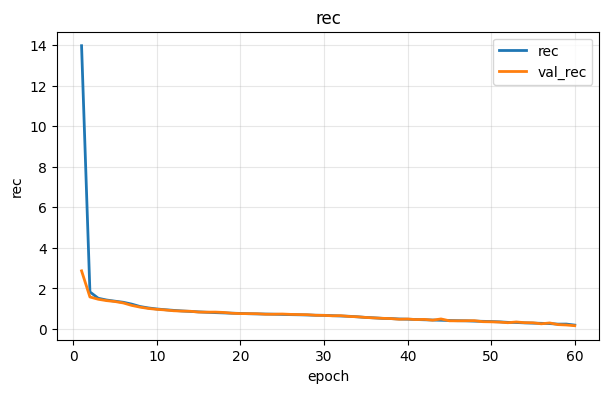

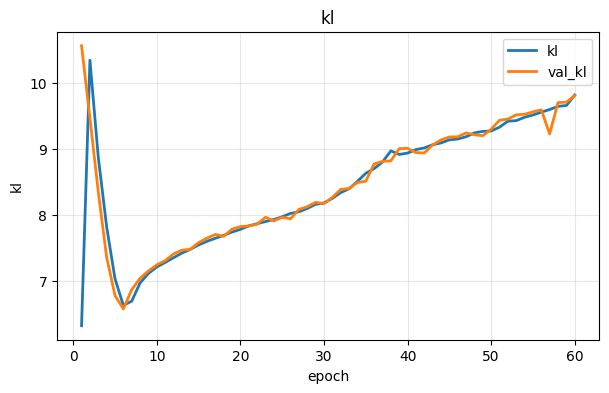

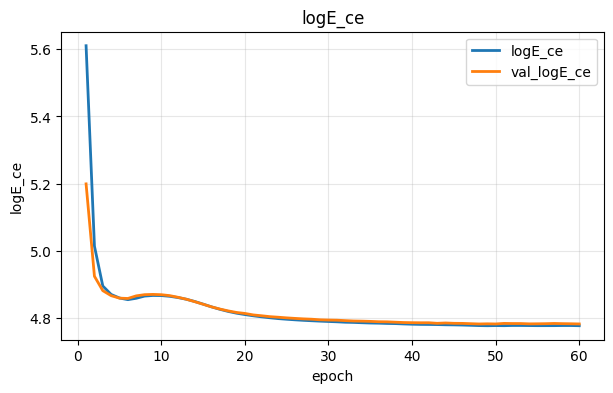

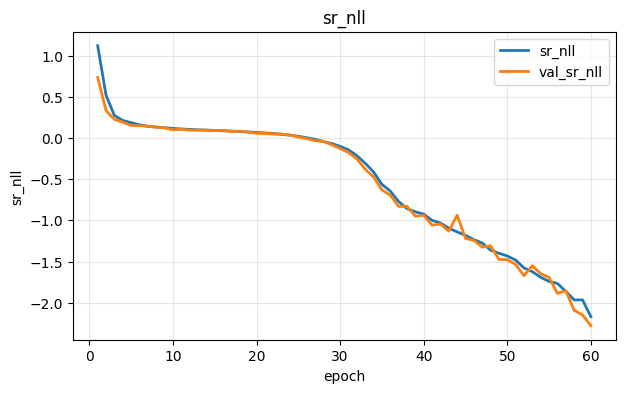

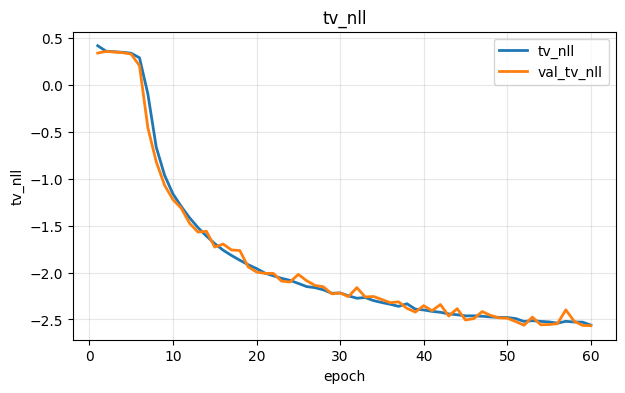

Metric not present: uv_mse


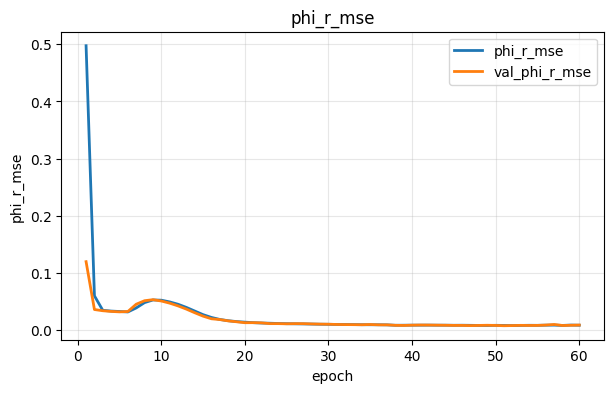

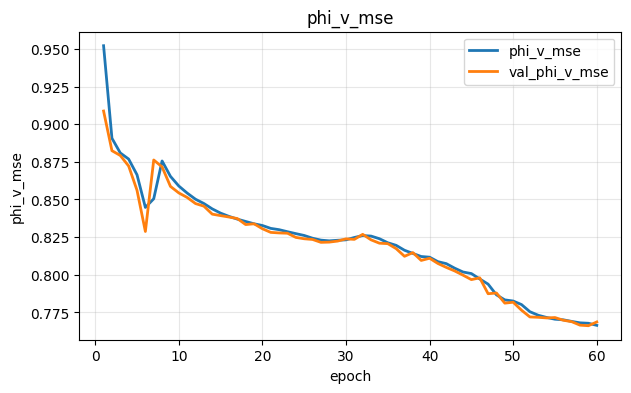

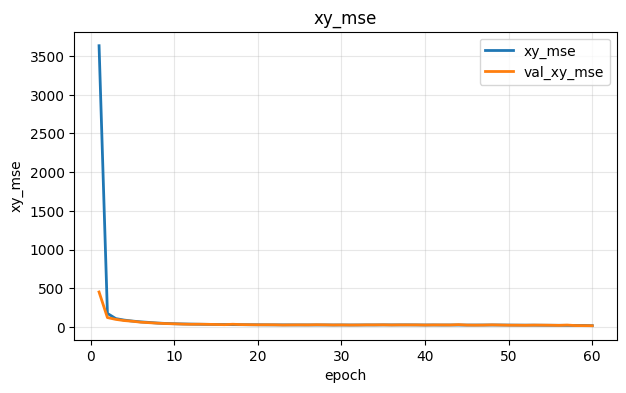

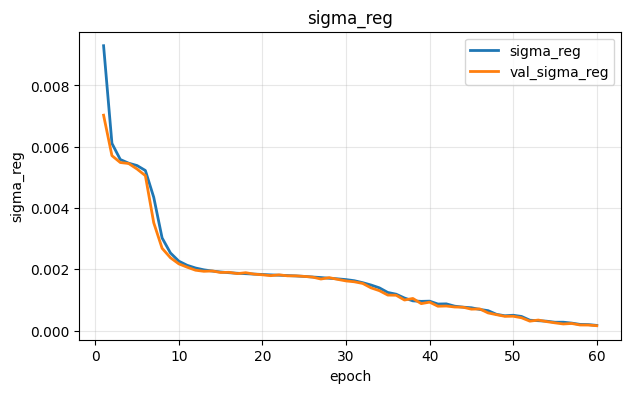

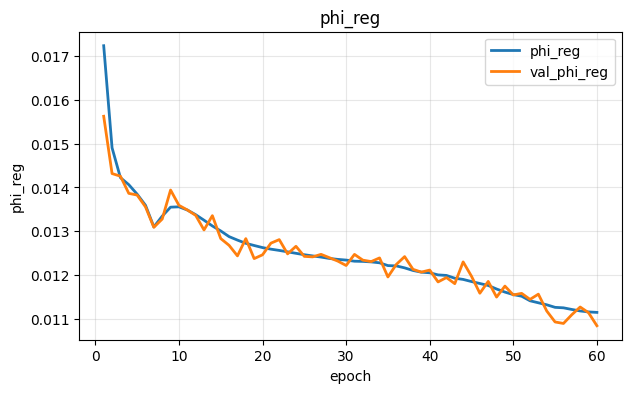

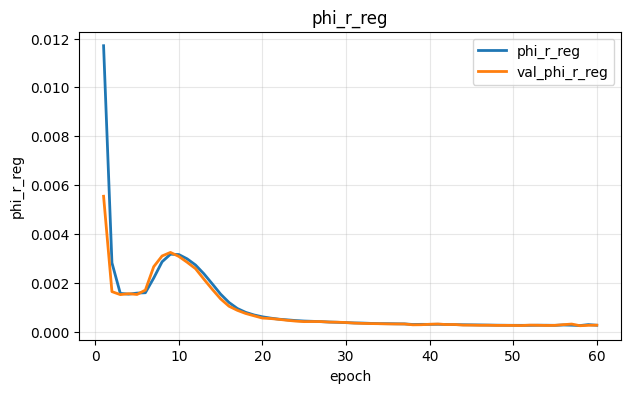

In [ ]:

def plot_history(history, keys=None, show_available=True):
    h = history.history

    if show_available:
        print("\nAvailable history keys:")
        print(list(h.keys()))

    # ==========================================================
    # Default metrics for CVAE_CatLogE_MixGaussTV
    # ==========================================================
    if keys is None:
        keys = [
            "loss",
            "rec",
            "kl",

            # energy
            "logE_ce",

            # polar position
            "sr_nll",

            # transformed polar direction modeled with a Gaussian mixture on t_v
            "tv_nll",

            # explicit loss on reconstructed u_v
            "uv_mse",

            # azimuthal directions
            "phi_r_mse",
            "phi_v_mse",

            # geometric loss
            "xy_mse",

            # regularizers
            "sigma_reg",
            "phi_reg",
            "phi_r_reg",
        ]

    # ==========================================================
    # Number of epochs
    # ==========================================================
    if "loss" in h:
        n_ep = len(h["loss"])
    else:
        n_ep = len(next(iter(h.values())))

    epochs = np.arange(1, n_ep + 1)

    has_lr = ("learning_rate" in h)

    # ==========================================================
    # Plotting
    # ==========================================================
    for k in keys:

        if k not in h:
            print("Metric not present:", k)
            continue

        plt.figure(figsize=(7, 4))

        plt.plot(
            epochs,
            h[k],
            label=k,
            linewidth=2
        )

        val_k = "val_" + k

        if val_k in h:
            plt.plot(
                epochs,
                h[val_k],
                label=val_k,
                linewidth=2
            )

        # Show learning rate only on the loss plot
        if k == "loss" and has_lr:
            ax1 = plt.gca()
            ax2 = ax1.twinx()

            ax2.plot(
                epochs,
                h["learning_rate"],
                linestyle="--",
                label="learning_rate"
            )

            ax2.set_ylabel("learning_rate")
            ax2.legend(loc="upper right")

        plt.xlabel("epoch")
        plt.ylabel(k)
        plt.title(k)

        plt.legend()
        plt.grid(True, alpha=0.3)

        plt.show()

# ==========================================================
# Standard usage
# ==========================================================
plot_history(history)

## Generation and Validation

In [31]:
def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

# ==========================================================
# Generate particle types
# ==========================================================
NGEN = len(X_test)   # 1:1 comparison with the test set

gen_type_idx = sample_types(NGEN, type_probs)
gen_cond = one_hot_from_idx(gen_type_idx, n_types)

unique, counts = np.unique(gen_type_idx, return_counts=True)

print("\nGenerated particle counts:")
for u, c in zip(unique, counts):
    print(idx_to_type[u], c)

# ==========================================================
# Generate features in training feature space
# y_gen_scaled = [logE_s, s_r_s, cphi_r, sphi_r, t_v_s, cphi_v, sphi_v]
# ==========================================================
y_gen_scaled = model.generate_y(gen_cond, NGEN).numpy().astype(np.float32)

# ==========================================================
# Unscale the scaled features
# - col 0 = logE
# - col 1 = s_r
# - col 4 = t_v
# ==========================================================
y_gen = y_gen_scaled.copy()

# unscale logE
y_gen[:, 0] = y_gen_scaled[:, 0] * logE_std + logE_mean

# unscale s_r
y_gen[:, 1] = y_gen_scaled[:, 1] * s_r_std + s_r_mean

# unscale t_v
y_gen[:, 4] = y_gen_scaled[:, 4] * t_v_std + t_v_mean

# ==========================================================
# Physical energy
# ==========================================================
E_gen = np.power(10.0, y_gen[:, 0], dtype=np.float32)

# ==========================================================
# Reconstruct physical directional variable from t_v
# t_v -> s_v -> u_v
# ==========================================================
t_v_gen = y_gen[:, 4]
s_v_gen = signed_expm1(t_v_gen)
u_v_gen = np.tanh(s_v_gen)

# ==========================================================
# Quick checks
# ==========================================================
print("\n--- Generated feature ranges ---")
print("logE_gen min/max:", y_gen[:, 0].min(), y_gen[:, 0].max())
print("s_r_gen  min/max:", y_gen[:, 1].min(), y_gen[:, 1].max())
print("t_v_gen  min/max:", t_v_gen.min(), t_v_gen.max())
print("s_v_gen  min/max:", s_v_gen.min(), s_v_gen.max())
print("u_v_gen  min/max:", u_v_gen.min(), u_v_gen.max())
print("E_gen    min/max:", E_gen.min(), E_gen.max())

print("\nGenerated fractions by type:")
for u, c in zip(unique, counts):
    print(f"{idx_to_type[u]:>8s}: {c / NGEN:.6f}")


Generated particle counts:
gamma 278975
e- 2065


NameError: name 'model' is not defined

In [ ]:
# Reconstruct position and direction from generated features
C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c * c + s * s) + eps
    return c / r, s / r

def u_from_s(s):
    # Map an unbounded variable s to u in (-1, 1)
    return np.tanh(s)

def signed_expm1(y):
    # Inverse of signed_log1p
    return np.sign(y) * np.expm1(np.abs(y))

# ==========================================================
# Extract generated features
# y = [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

s_r_gen = y_gen[:, 1]
u_r_gen = u_from_s(s_r_gen)

t_v_gen = y_gen[:, 4]
s_v_gen = signed_expm1(t_v_gen)
u_v_gen = u_from_s(s_v_gen)

# ==========================================================
# Position on the sphere
# ==========================================================

cpr_gen, spr_gen = renorm_cos_sin(y_gen[:, 2], y_gen[:, 3])
sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen * u_r_gen))

x_gen = C[0] + R * sin_tr_gen * cpr_gen
ypos_gen = C[1] + R * sin_tr_gen * spr_gen
z_gen = C[2] + R * u_r_gen

# ==========================================================
# Direction: (t_v, phi_v) -> s_v -> u_v -> (vx, vy, vz)
# ==========================================================

# Clip only for numerical safety after tanh
u_v_gen = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

cpv_gen, spv_gen = renorm_cos_sin(y_gen[:, 5], y_gen[:, 6])
sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen * u_v_gen))

vx_gen = sin_tv_gen * cpv_gen
vy_gen = sin_tv_gen * spv_gen
vz_gen = u_v_gen

# ==========================================================
# Sanity checks on geometric constraints
# ==========================================================

rvec_gen = np.vstack([x_gen, ypos_gen, z_gen]).T - C[None, :]
r_gen = np.linalg.norm(rvec_gen, axis=1)

vnorm_gen_check = np.sqrt(vx_gen * vx_gen + vy_gen * vy_gen + vz_gen * vz_gen)

phi_r_norm = np.sqrt(cpr_gen * cpr_gen + spr_gen * spr_gen)
phi_v_norm = np.sqrt(cpv_gen * cpv_gen + spv_gen * spv_gen)

print("--- CONSTRAINT CHECKS ---")
print("r_gen: mean", r_gen.mean(), "std", r_gen.std(), "min", r_gen.min(), "max", r_gen.max())
print("mean |r-R| =", np.mean(np.abs(r_gen - R)))

print("||v||: mean", vnorm_gen_check.mean(), "std", vnorm_gen_check.std(),
      "min", vnorm_gen_check.min(), "max", vnorm_gen_check.max())
print("mean ||v||-1| =", np.mean(np.abs(vnorm_gen_check - 1.0)))

print("phi_r norm: mean", phi_r_norm.mean(), "std", phi_r_norm.std(),
      "min", phi_r_norm.min(), "max", phi_r_norm.max())
print("phi_v norm: mean", phi_v_norm.mean(), "std", phi_v_norm.std(),
      "min", phi_v_norm.min(), "max", phi_v_norm.max())

print("E_gen: min", E_gen.min(), "max", E_gen.max())
print("u_r_gen min/max:", u_r_gen.min(), u_r_gen.max())
print("t_v_gen min/max:", t_v_gen.min(), t_v_gen.max())
print("s_v_gen min/max:", s_v_gen.min(), s_v_gen.max())
print("u_v_gen min/max:", u_v_gen.min(), u_v_gen.max())
print("fraction u_v_gen > 0:", np.mean(u_v_gen > 0))

--- CONSTRAINT CHECKS ---
r_gen: mean 99.99999956735161 std 9.217640102493896e-06 min 99.99996874278781 max 100.00003901822711
mean |r-R| = 7.095198518559142e-06
||v||: mean 1.0 std 3.660572e-08 min 0.9999998 max 1.0000001
mean ||v||-1| = 1.8725071e-08
phi_r norm: mean 1.0 std 3.877948e-08 min 0.9999998 max 1.0000001
phi_v norm: mean 1.0 std 3.6484305e-08 min 0.9999998 max 1.0000001
E_gen: min 0.0014521545 max 1.214444
u_r_gen min/max: -1.0 0.99999994
t_v_gen min/max: -2.043349 0.5321481
s_v_gen min/max: -6.7164083 0.70258576
u_v_gen min/max: -0.9999971 0.6060065
fraction u_v_gen > 0: 0.028739681184173072


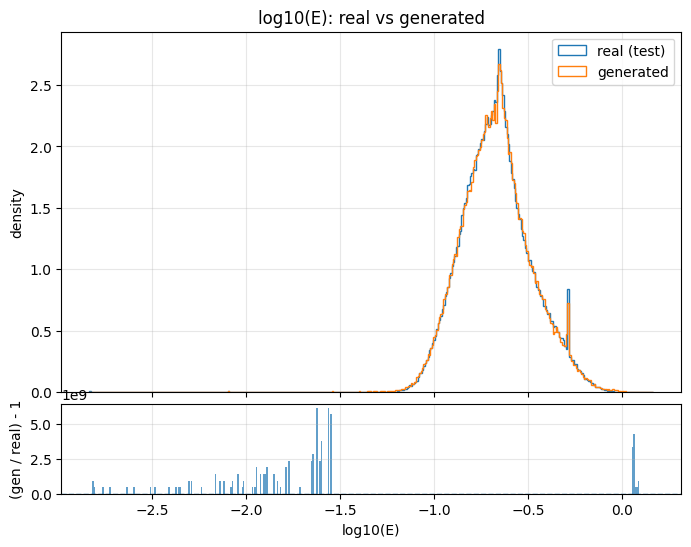

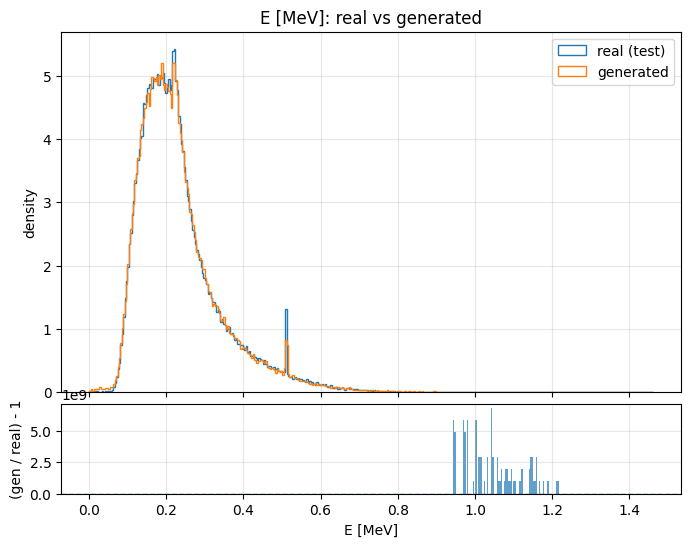

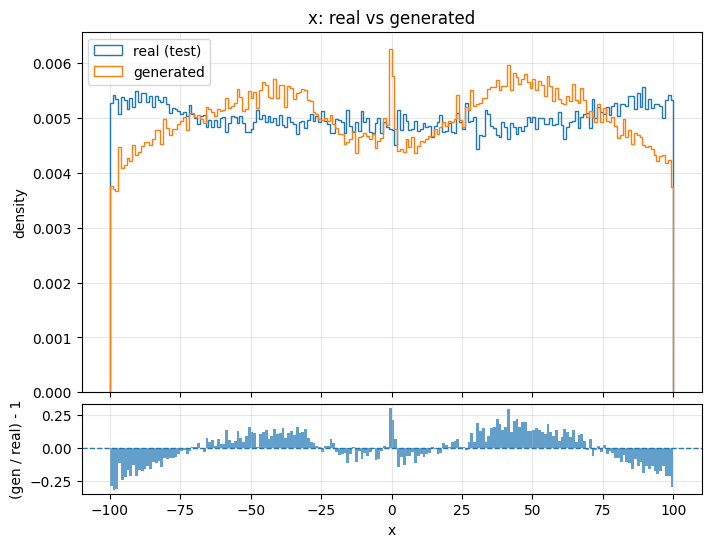

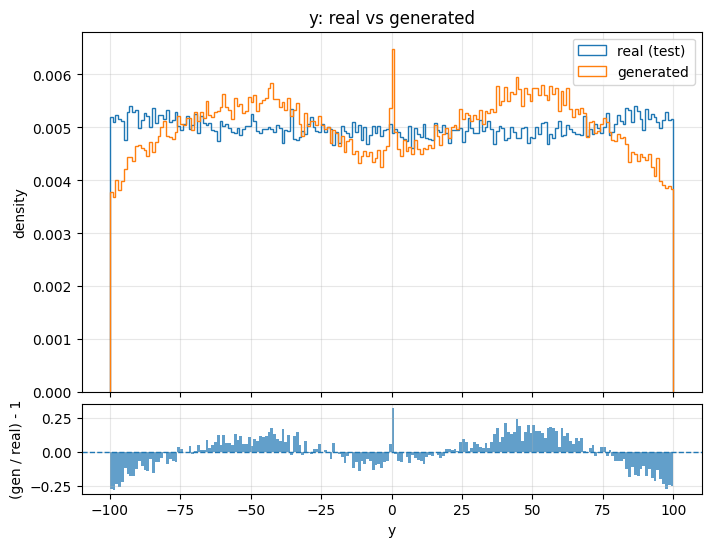

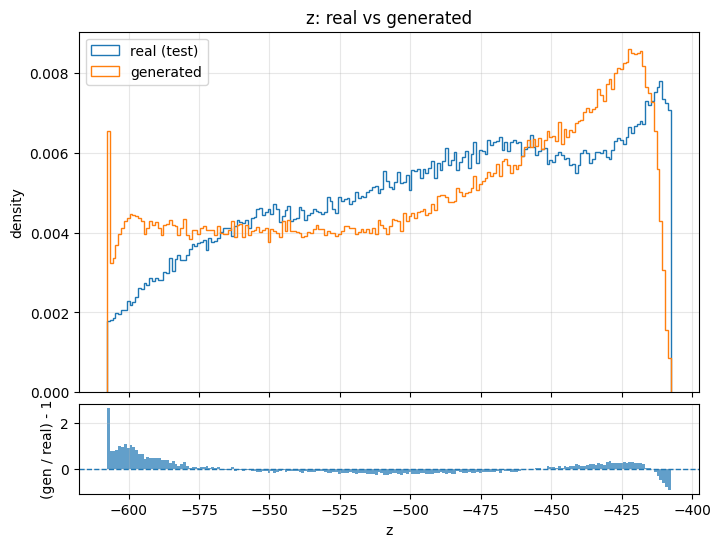

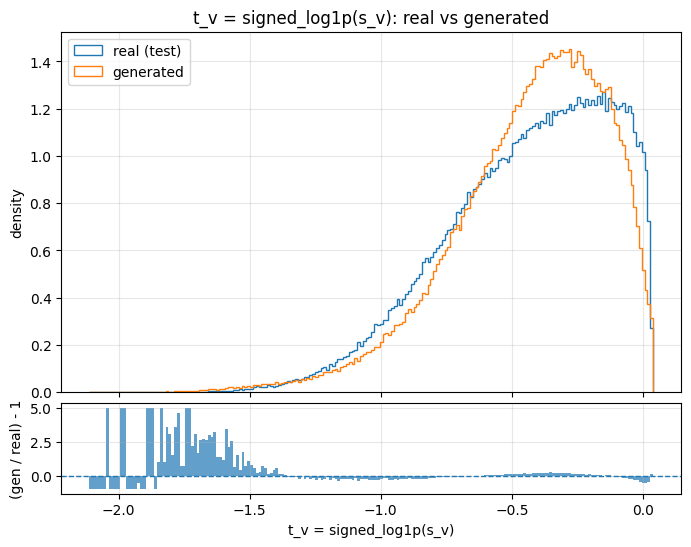

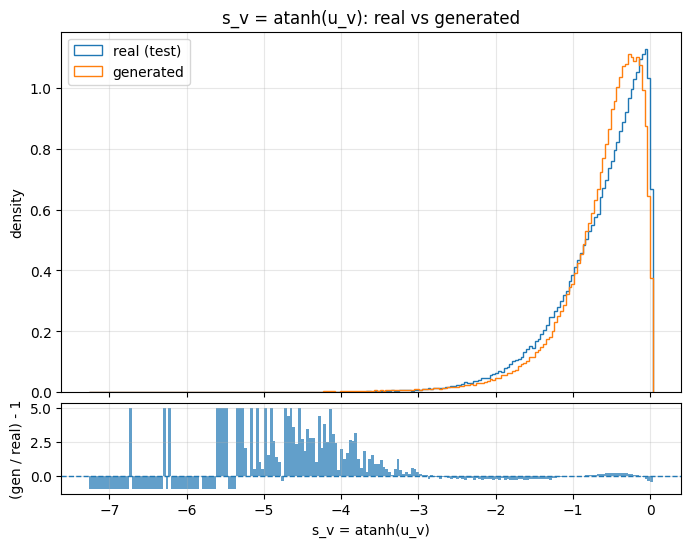

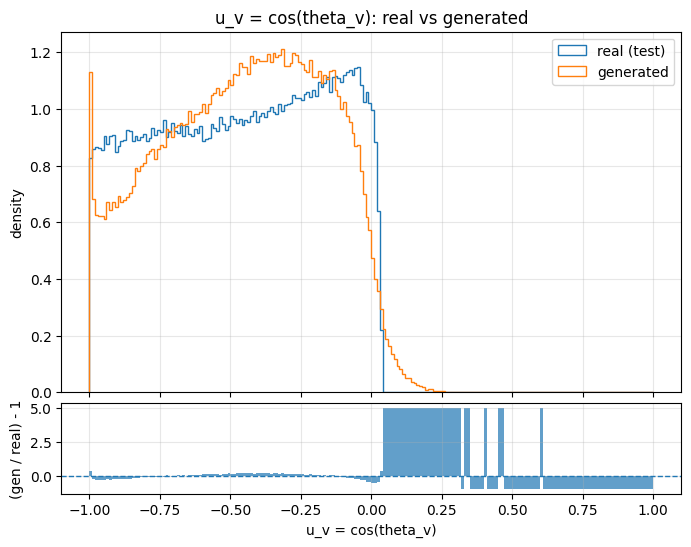

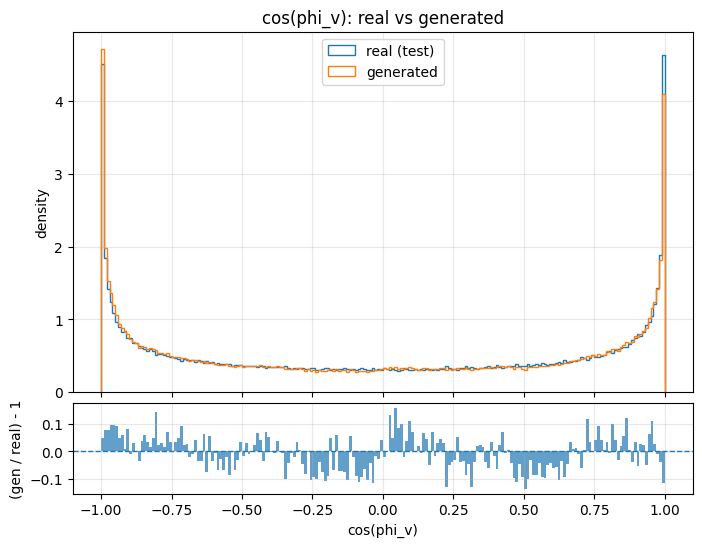

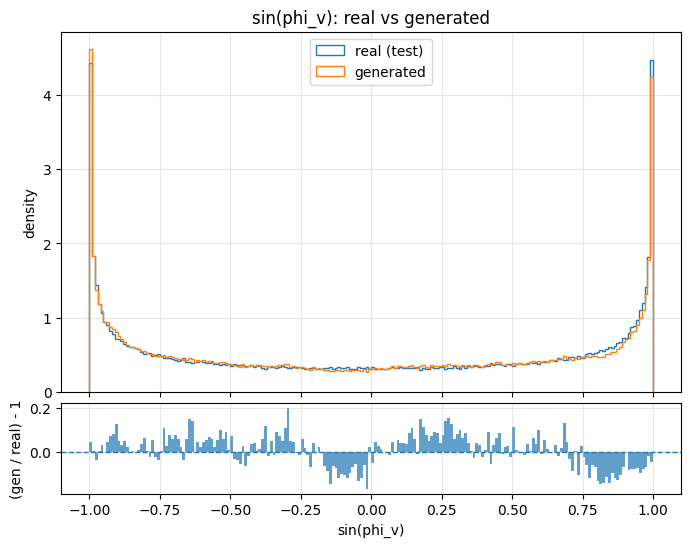

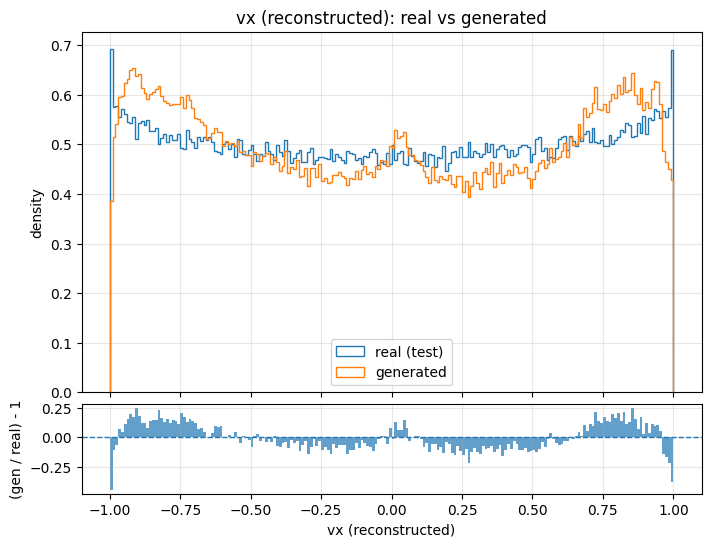

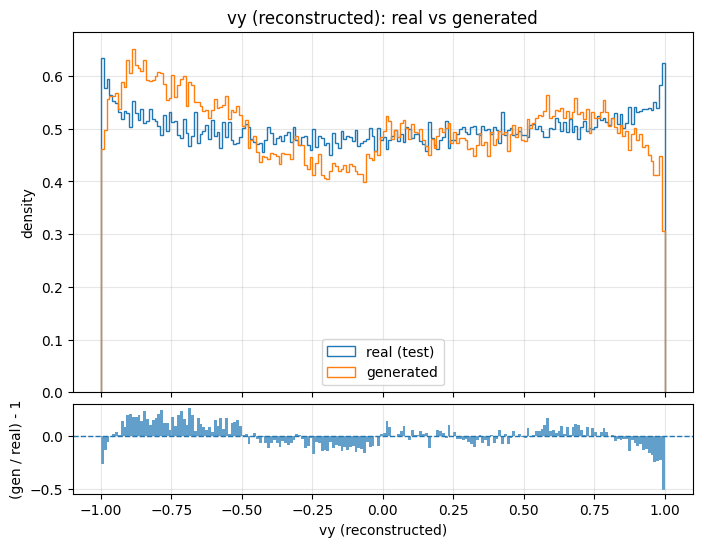

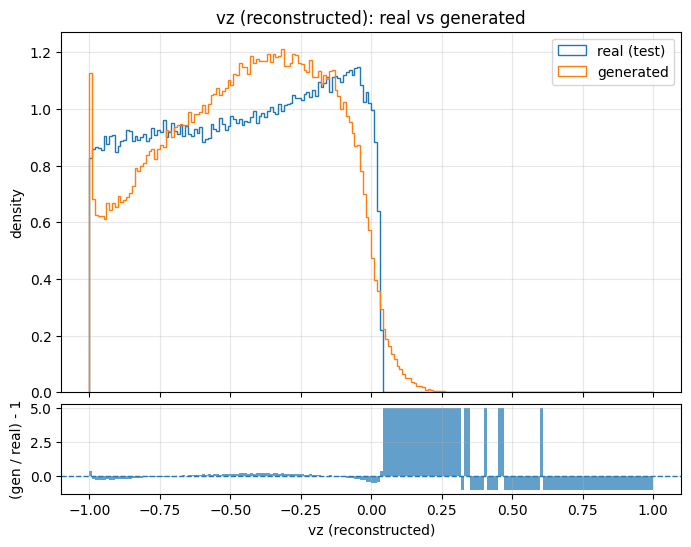


--- RANGE CHECK ---
logE real/gen: -2.833067 0.1645967 | -2.8379872 0.08437753
x real/gen: -99.99797 99.99979 | -99.999565 99.99986
y real/gen: -99.99984 99.99965 | -99.999725 99.99993
z real/gen: -607.6554 -407.6604 | -607.66003 -407.66
t_v real/gen: -2.111155 0.038704 | -2.043349 0.5321481
s_v real/gen: -7.257774 0.039462756 | -6.7164083 0.70258576
u_v real/gen: -0.999999 0.039442282 | -0.9999971 0.60600656
cos(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
sin(phi_v) real/gen: -1.0 1.0 | -1.0 1.0
vx rec real/gen: -0.9999941 0.9999954 | -0.9999816 0.9999868
vy rec real/gen: -0.9999958 0.9999981 | -0.9999929 0.9999762
vz rec real/gen: -0.999999 0.039442282 | -0.9999971 0.60600656

--- COS/SIN NORM CHECK ---
phi_r real/gen: 1.0 1.0
phi_v real/gen: 1.0 1.0


In [ ]:
eps = 1e-6

def signed_expm1(y):
    return np.sign(y) * np.expm1(np.abs(y))

# ==========================================================
# REAL TEST DATA in physical / unscaled feature space
# layout: [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

# Use the explicit RAW copy created in the split cell
# (fallback to X_test if not available)
if "X_test_unscaled" in globals():
    X_real = X_test_unscaled.copy()
else:
    X_real = X_test.copy()

# -------------------------------
# Real energy
# -------------------------------
logE_real_test = X_real[:, 0]
E_real_test = np.power(10.0, logE_real_test, dtype=np.float32)

# -------------------------------
# Real position
# -------------------------------
s_r_real = X_real[:, 1]
u_r_real = np.tanh(s_r_real)

cphi_r_real = X_real[:, 2].copy()
sphi_r_real = X_real[:, 3].copy()

norm_r = np.sqrt(cphi_r_real**2 + sphi_r_real**2) + 1e-12
cphi_r_real /= norm_r
sphi_r_real /= norm_r

sin_tr_real = np.sqrt(np.maximum(0.0, 1.0 - u_r_real**2))

x_real = C[0] + R * sin_tr_real * cphi_r_real
y_real = C[1] + R * sin_tr_real * sphi_r_real
z_real = C[2] + R * u_r_real

# -------------------------------
# Real direction
# t_v -> s_v -> u_v
# -------------------------------
t_v_real = X_real[:, 4].copy()
s_v_real = signed_expm1(t_v_real)
u_v_real = np.tanh(s_v_real)
u_v_real = np.clip(u_v_real, -1.0 + eps, 1.0 - eps)

cphi_v_real = X_real[:, 5].copy()
sphi_v_real = X_real[:, 6].copy()

norm_v = np.sqrt(cphi_v_real**2 + sphi_v_real**2) + 1e-12
cphi_v_real /= norm_v
sphi_v_real /= norm_v

sin_tv_real = np.sqrt(np.maximum(0.0, 1.0 - u_v_real**2))
vx_real = sin_tv_real * cphi_v_real
vy_real = sin_tv_real * sphi_v_real
vz_real = u_v_real

vnorm_real = np.sqrt(vx_real**2 + vy_real**2 + vz_real**2) + 1e-12
vx_real /= vnorm_real
vy_real /= vnorm_real
vz_real /= vnorm_real

# ==========================================================
# GENERATED DATA
# y_gen layout: [logE, s_r, cphi_r, sphi_r, t_v, cphi_v, sphi_v]
# ==========================================================

logE_gen = y_gen[:, 0]
E_gen = np.power(10.0, logE_gen, dtype=np.float32)

# -------------------------------
# Generated position
# -------------------------------
s_r_gen = y_gen[:, 1]
u_r_gen = np.tanh(s_r_gen)

cphi_r_gen = y_gen[:, 2].copy()
sphi_r_gen = y_gen[:, 3].copy()

norm_rg = np.sqrt(cphi_r_gen**2 + sphi_r_gen**2) + 1e-12
cphi_r_gen /= norm_rg
sphi_r_gen /= norm_rg

sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen**2))

x_gen = C[0] + R * sin_tr_gen * cphi_r_gen
ypos_gen = C[1] + R * sin_tr_gen * sphi_r_gen
z_gen = C[2] + R * u_r_gen

# -------------------------------
# Generated direction
# t_v -> s_v -> u_v
# -------------------------------
t_v_gen = y_gen[:, 4].copy()
s_v_gen = signed_expm1(t_v_gen)
u_v_gen = np.tanh(s_v_gen)
u_v_gen = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

cphi_v_gen = y_gen[:, 5].copy()
sphi_v_gen = y_gen[:, 6].copy()

norm_vg = np.sqrt(cphi_v_gen**2 + sphi_v_gen**2) + 1e-12
cphi_v_gen /= norm_vg
sphi_v_gen /= norm_vg

sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen**2))
vx_gen_rec = sin_tv_gen * cphi_v_gen
vy_gen_rec = sin_tv_gen * sphi_v_gen
vz_gen = u_v_gen

vnorm_gen = np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2) + 1e-12
vx_gen_rec /= vnorm_gen
vy_gen_rec /= vnorm_gen
vz_gen /= vnorm_gen

# ==========================================================
# Plot function with residual panel
# Residuals are shown as (gen / real) - 1
# ==========================================================
def compare_hist_with_residuals(
    real,
    gen,
    name,
    bins=200,
    range_=None,
    eps_res=1e-12,
    ratio_clip=None,
):
    """
    Residual panel shows:
        (gen_density / real_density) - 1

    Parameters
    ----------
    real, gen : array-like
        Real and generated samples.
    name : str
        Variable name to show in the title/x-axis.
    bins : int or array-like
        Histogram binning.
    range_ : tuple or None
        Optional histogram range.
    eps_res : float
        Small floor to avoid division by zero.
    ratio_clip : float or None
        If provided, clip residuals to [-ratio_clip, +ratio_clip]
        for better visualization.
    """
    real = np.asarray(real)
    gen = np.asarray(gen)

    # Histograms with common binning
    real_hist, bin_edges = np.histogram(real, bins=bins, range=range_, density=True)
    gen_hist, _ = np.histogram(gen, bins=bin_edges, density=True)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    # Ratio residuals
    residuals = gen_hist / np.maximum(real_hist, eps_res) - 1.0
    resid_ylabel = "(gen / real) - 1"

    if ratio_clip is not None:
        residuals = np.clip(residuals, -ratio_clip, ratio_clip)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
    )

    # Top panel: histograms
    ax_top.hist(real, bins=bin_edges, density=True, histtype="step", label="real (test)")
    ax_top.hist(gen,  bins=bin_edges, density=True, histtype="step", label="generated")
    ax_top.set_ylabel("density")
    ax_top.set_title(f"{name}: real vs generated")
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)

    # Bottom panel: residuals as ratio-1
    ax_bot.axhline(0.0, linestyle="--", linewidth=1)
    ax_bot.bar(bin_centers, residuals, width=bin_widths, align="center", alpha=0.7)
    ax_bot.set_xlabel(name)
    ax_bot.set_ylabel(resid_ylabel)
    ax_bot.grid(True, alpha=0.3)

    plt.show()

# ==========================================================
# PLOTS: Energy
# ==========================================================
compare_hist_with_residuals(logE_real_test, logE_gen, "log10(E)", bins=400)
compare_hist_with_residuals(E_real_test, E_gen, "E [MeV]", bins=400)

# ==========================================================
# PLOTS: Reconstructed position
# ==========================================================
compare_hist_with_residuals(x_real, x_gen, "x", ratio_clip=5)
compare_hist_with_residuals(y_real, ypos_gen, "y", ratio_clip=5)
compare_hist_with_residuals(z_real, z_gen, "z", ratio_clip=5)

# ==========================================================
# PLOTS: Direction features
# ==========================================================
compare_hist_with_residuals(t_v_real,    t_v_gen,    "t_v = signed_log1p(s_v)", ratio_clip=5)
compare_hist_with_residuals(s_v_real,    s_v_gen,    "s_v = atanh(u_v)", ratio_clip=5)
compare_hist_with_residuals(u_v_real,    u_v_gen,    "u_v = cos(theta_v)", range_=(-1, 1), ratio_clip=5)
compare_hist_with_residuals(cphi_v_real, cphi_v_gen, "cos(phi_v)", range_=(-1, 1), ratio_clip=5)
compare_hist_with_residuals(sphi_v_real, sphi_v_gen, "sin(phi_v)", range_=(-1, 1), ratio_clip=5)

# ==========================================================
# PLOTS: Reconstructed Cartesian direction
# ==========================================================
compare_hist_with_residuals(vx_real, vx_gen_rec, "vx (reconstructed)", range_=(-1, 1), ratio_clip=5)
compare_hist_with_residuals(vy_real, vy_gen_rec, "vy (reconstructed)", range_=(-1, 1), ratio_clip=5)
compare_hist_with_residuals(vz_real, vz_gen,     "vz (reconstructed)", range_=(-1, 1), ratio_clip=5)

# ==========================================================
# Range checks
# ==========================================================
print("\n--- RANGE CHECK ---")
print("logE real/gen:", logE_real_test.min(), logE_real_test.max(), "|", logE_gen.min(), logE_gen.max())

print("x real/gen:", x_real.min(), x_real.max(), "|", x_gen.min(), x_gen.max())
print("y real/gen:", y_real.min(), y_real.max(), "|", ypos_gen.min(), ypos_gen.max())
print("z real/gen:", z_real.min(), z_real.max(), "|", z_gen.min(), z_gen.max())

print("t_v real/gen:", t_v_real.min(), t_v_real.max(), "|", t_v_gen.min(), t_v_gen.max())
print("s_v real/gen:", s_v_real.min(), s_v_real.max(), "|", s_v_gen.min(), s_v_gen.max())
print("u_v real/gen:", u_v_real.min(), u_v_real.max(), "|", u_v_gen.min(), u_v_gen.max())

print("cos(phi_v) real/gen:", cphi_v_real.min(), cphi_v_real.max(), "|", cphi_v_gen.min(), cphi_v_gen.max())
print("sin(phi_v) real/gen:", sphi_v_real.min(), sphi_v_real.max(), "|", sphi_v_gen.min(), sphi_v_gen.max())

print("vx rec real/gen:", vx_real.min(), vx_real.max(), "|", vx_gen_rec.min(), vx_gen_rec.max())
print("vy rec real/gen:", vy_real.min(), vy_real.max(), "|", vy_gen_rec.min(), vy_gen_rec.max())
print("vz rec real/gen:", vz_real.min(), vz_real.max(), "|", vz_gen.min(), vz_gen.max())

# Check cos/sin norms
norm_phi_r_real = np.sqrt(cphi_r_real**2 + sphi_r_real**2)
norm_phi_r_gen  = np.sqrt(cphi_r_gen**2  + sphi_r_gen**2)
norm_phi_v_real = np.sqrt(cphi_v_real**2 + sphi_v_real**2)
norm_phi_v_gen  = np.sqrt(cphi_v_gen**2  + sphi_v_gen**2)

print("\n--- COS/SIN NORM CHECK ---")
print("phi_r real/gen:", norm_phi_r_real.mean(), norm_phi_r_gen.mean())
print("phi_v real/gen:", norm_phi_v_real.mean(), norm_phi_v_gen.mean())